# API Tutorial of Event Related Potentials (ERPs) Simulation

This example demonstrates how to simulate an event-related potential (ERP) using the HNN Python API.

The workflow below recreates examples of the tactile evoked response as observed in Jones et al., J. Neuroscience 2007 [1] and as detailed in the [ERP Tutorial]() on our [HNN Textbook Website](https://jonescompneurolab.github.io/textbook/content/preface.html)


In [1]:
# Authors:
#   Dylan Daniels <dylan_s_daniels@alumni.brown.edu>

# Textbook Section 4.2

## Set Up Your HNN Environment

We assume for this walkthrough that you have access to the latest stable version of the `hnn-core` software. If not, please follow the instructions on our [Installation page](https://jonescompneurolab.github.io/textbook/content/01_getting_started/installation.html) to step up HNN. We also recommend reading the remainer of this page in full, as there are additional instructions for following along with the ERP walkthrough.

Note that the [Installation page](https://jonescompneurolab.github.io/textbook/content/01_getting_started/installation.html) includes instructions for running HNN "on the cloud" and for installing HNN locally on your personal machine. While the cloud versions of HNN can be relatively easy to get up and running, they do come with certain limitations (such as limited access to compute cores in the case of Google CoLab). As such, we recommend that you install HNN on your local machine using the `conda` installation method. However, if you are unable to install HNN locally, using one of the cloud methods is a perfectly viable alternative. 

The (recommended) `conda` installation method will install the latest **stable** version of `hnn-core` on your device, including the Graphical User Interface (GUI) and other dependencies for running faster simulations using parallelism (i.e., multuiple processor cores).

Once you have completed the `conda` installation instructions, you can activate your conda environment with the following Command Line command:

```bash
conda activate hnn-core-env
```

You can then launch the GUI from the active conda environment with the following command:

```bash
hnn-gui
```

### Following Along With the Textbook's Python API Tutorials


Note that any code blocks on the subsequent pages of the **Simulating ERPs** walkthrough are *cumulative*. That is to say, these code blocks are meant to be run in sequential order, as they are drawn from a single `ipython` notebook file. 

By clicking the `Download Notebook` button at the top of this page, you can download the entire `.ipynb` file and run it interactively through Jupyter Notebook or through your preferred code editor (VS Code, Pycharm, etc.).

Keep in mind that your code editor may install additional dependencies needed to open and run `.ipynb` files when using the `hnn-core-env` conda environment. 

If you would like to launch a Jupyter Notebook server directly from the Command Line, you will need to install Jupyter's `notebook` dependency directly into `hnn-core-env`. To do so, run the following command from your active `hnn-core-env` conda environment:

```bash
conda install -c conda-forge notebook
```

After installation, you can launch the jupyter server with the following command:

```bash
jupyter notebook
```

Alternatively, you can start an interactive ipython environment with the command below. This will allow you to run individual commands from your Command Line interface without needing to install the additional `notebook` dependency from Jupyter.  

```bash
ipython
```

### Accessing Data and Network Files

At various points in the tutorials, we will reference particular network and/or data files. These files can be found on our [hnn-data GitHub repository](https://github.com/jonescompneurolab/hnn-data/)

In brief, the `MEG_detection_data` subdirectory contains the experimental MEG data referenced in our Jones et al. (2007) study, while the `network-configurations` subdirectory contains various network configuration files for simulating ERPs and rhythms

We recommend that you clone this repository to your local machine, as you will need several of these files to follow along with the tutorials

You can clone this repository with the following command:

```bash
git clone https://github.com/jonescompneurolab/hnn-data.git
```

We will periodically update or add new network configuration files, so we recommend occasionally pulling the latest changes from GitHub. You can do so with the following commands:

```bash
git checkout main
git pull origin main
```


# Textbook Section 4.4

## Using the HNN Python API

### Import HNN and Instantiate a Model

Once you've set up your `hnn-core` environment, you are ready to use HNN's Python API. The very first thing you'll want to do (after activating your environment) is to import the `hnn_core` package

We'll also import one of the default models, `jones_2009_model`, which is the laminar SI model as originally presented in Jones et al., 2009.

In [2]:
import hnn_core  # noqa
from hnn_core import jones_2009_model

--No graphics will be displayed.


The HNN Python API is designed around the network object, which we will interact with to set parameters, run simulations, view simulation outputs, and more. 

We can create an instance of the default `jones_2009_model` by assigning it to a variable, such as net_default.

In [3]:
net_default = jones_2009_model()

### Interacting with the Network Object

We can then interact with the `network` object by using its available attributes

For example, the code block below will print the public-facing methods and data attributes that are available. For simplicity, we will only print the "public" attributes. There are additional "private" attributes that advanced users may want to interact with

In [4]:
# get all available attributes
attributes = dir(net_default)

# get the available *methods* (functions) that act on the network object
methods = [
    attr
    for attr in attributes
    # limit to attributes that *are* callable
    if callable(getattr(net_default, attr))
    and
    # exclude "private" attributes
    not attr.startswith("_")
]

# get the available *data attributes* that are associated with the
# network object
data_attributes = [
    attr
    for attr in attributes
    # limit to attributes that *are not* callable
    if not callable(getattr(net_default, attr))
    and
    # exclude "private" attributes
    not attr.startswith("_")
]

# print public methods
print("Methods:")
print(*methods, sep=", ")

# print public data attributes
print("\nData attributes:")
print(*data_attributes, sep=", ")

Methods:
add_bursty_drive, add_connection, add_electrode_array, add_evoked_drive, add_poisson_drive, add_spike_train_drive, add_tonic_bias, clear_connectivity, clear_drives, copy, filter_cell_types, get_global_synaptic_gains, gid_to_type, plot_cells, set_cell_positions, set_global_synaptic_gains, to_dict, write_configuration

Data attributes:
cell_response, cell_types, connectivity, delay, external_biases, external_drives, gid_ranges, pos_dict, rec_arrays, threshold


We can then use these attributes with the network object we instantiated previously

First, let's try examining one of the network's data attributes: `cell_types`. We can check the object's `type` so we know how to interact with it

In [5]:
# check the `net.cell_types` object's type
print(f"Object type: {type(net_default.cell_types)}")

Object type: <class 'dict'>


Now that we have confirmed the `net.cell_types` object is a dictionary, we know how to ineract with it using native Python code

Next, let's print the dictionary's keys, which in this case will tell us the unique cell types in the network

In [6]:
print("Cell types:")

# loop through the dictionary keys and print them
for key in net_default.cell_types.keys():
    print(f"\t{key}")

Cell types:
	L2_basket
	L2_pyramidal
	L5_basket
	L5_pyramidal


Let's examine one of these `cell_types` objects in more detail. We'll use "L5_pyramidal" as an example, and we'll assign it a variable for easier access

In [7]:
# assign net_default.cell_types["L5_pyramidal"] to a variable
l5_pyr_celltype = net_default.cell_types["L5_pyramidal"]

# check its type
print(type(l5_pyr_celltype))

<class 'dict'>


Once again, we have a dictionary. We can loop through it and print the dictionary keys and values to better understand the object's data structure

In [8]:
for key, value in l5_pyr_celltype.items():
    print(f'Key: "{key}"')
    print("Value:")
    print(f"   Type:  {type(value)}")
    print(f"   Value: {value}")
    print("\n" + "-" * 20 + "\n")


Key: "cell_object"
Value:
   Type:  <class 'hnn_core.cell.Cell'>
   Value: <Cell | gid=None>

--------------------

Key: "cell_metadata"
Value:
   Type:  <class 'dict'>
   Value: {'morpho_type': 'pyramidal', 'electro_type': 'excitatory', 'layer': '5', 'measure_dipole': True, 'reference': 'https://doi.org/10.7554/eLife.51214', 'color': 'b', 'marker': '^'}

--------------------



We can see that this yields another dictionary with two keys. The first is "cell_object", which contains a class called `hnn_core.cell.Cell`. We will explore this class further in upcoming sections

The second is "cell_metadata", which contains a dictionary with information about the "L5_pyramidal" cell type. 

### Visualizing the Network and Cell objects

Next, let's try using one of the network's **methods**: `plot_cells()`. This will plot a diagram of the network that shows all of the cell types in a 3D grid

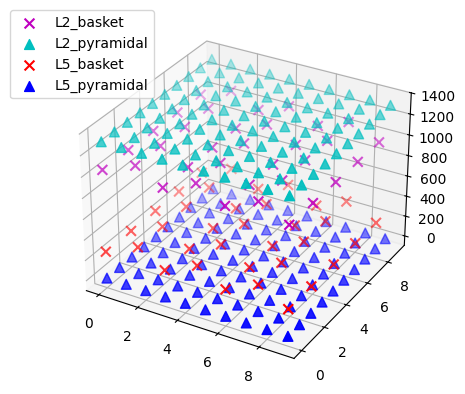

In [9]:
# we can plot a diagram of the network using the .plot_cells() method
_ = net_default.plot_cells()

The `hnn_core.cell.Cell` class also contains its own set of methods and data attributes. For example, we can plot the morphology of the "L5_pyramidal" cell using the `.plot_morphology()` method

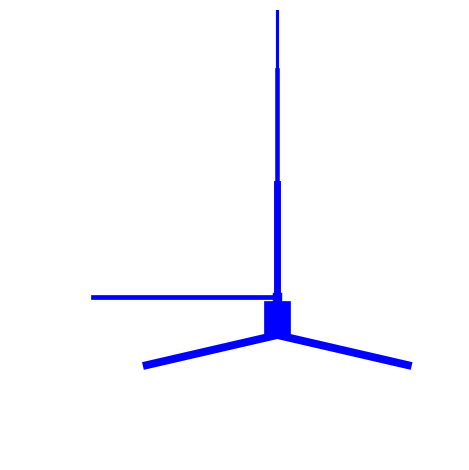

In [10]:
# using the variable we created above, we can access the `Cell` class
# object and plot its morphology

# remember: l5_pyr_celltype is a dictionary, so we need to use the
# "cell_object" key to access the `Cell` class for plotting

_ = l5_pyr_celltype["cell_object"].plot_morphology()

# Textbook Section 4.5

## Simulate the Default Network

Let's begin by importing all of the dependencies we will need for this section of the tutorial

In [11]:
from urllib.request import urlretrieve

import matplotlib.pyplot as plt
from hnn_core import (
    JoblibBackend,
    MPIBackend,
    read_dipole,
    simulate_dipole,
)
from hnn_core.network_models import add_erp_drives_to_jones_model
from hnn_core.viz import plot_dipole

### Load Experimental Data

Following the typical experimental workflow outlined in the [Simulation Workflow](https://jonescompneurolab.github.io/textbook/content/05_erps/erp_simulation_workflow.html) page, we will begin by importing some real experimental MEG data.

As a reminder, the data we use in these tutorials are from the Jones et al. 2007 study, as detailed in the [Introduction and ERP Overview](https://jonescompneurolab.github.io/textbook/content/05_erps/erp_overview.html) page. 

Using the code below, we can fetch the data for the treshold-level tacile evoked response directly from our lab's `hnn-data` GitHub repository. (If you prefer, you can also clone the `hnn-data` repository to your local machine and import the data from there)

In [12]:
# link to the data in the `hnn-data` GitHub repository
data_url = "https://raw.githubusercontent.com/jonescompneurolab/hnn-data/main/MEG_detection_data/yes_trial_S1_ERP_all_avg.txt"
urlretrieve(
    data_url,
    "yes_trial_S1_ERP_all_avg.txt",
);

Once we've fetched the data, we can load it with the `read_dipole()` function and assign it to a variable; in this case, we assign it to the variable named `threshold_experimental_dpl`. This process will load the experimental data as a `Dipole` object that can be used with `hnn-core`. 

The `Dipole` object has various attributes that we will not explore in detail at this time. For now, we will focus on two specific data attributes: `times` and `data`. 

Let's examine these attributes in more detail.

In [13]:
# load the experimental data as a `Dipole` object and
# assign it to a variable
threshold_experimental_dpl = read_dipole(
    "yes_trial_S1_ERP_all_avg.txt",
)

# assign the `times` data attribute to a variable
threshold_times = threshold_experimental_dpl.times

# assign the `data` data attribute to a variable
threshold_data = threshold_experimental_dpl.data

print(
    f"Object type: {type(threshold_experimental_dpl)}",
    f"  Data type: {type(threshold_data)}",
    f" Times type: {type(threshold_times)}",
    sep="\n",
)

Object type: <class 'hnn_core.dipole.Dipole'>
  Data type: <class 'dict'>
 Times type: <class 'numpy.ndarray'>


We can see that the `data` attribute is a dictionary, while the `times` attribute is an array. As the names imply, the current dipole data are stored in the `data` dictionary, while the timesteps are stored directly in the `times` attribute.  

Let's examine the `data` dictionary in more detail, printing its keys and value types.

In [14]:
print(
    "# Examining the `data` dictionary:",
    "# " + "-" * 40,
    sep="\n",
)

for key, value in threshold_data.items():
    print(
        f'Key: "{key}"',
        f"    Value type: {type(value)}",
        sep="\n",
    )

# Examining the `data` dictionary:
# ----------------------------------------
Key: "agg"
    Value type: <class 'numpy.ndarray'>


We can see that the `data` dictionary has a single key named `agg` that points to an array.

Since the source data `yes_trial_S1_ERP_all_avg.txt` has two columns (you can verify this by pasting the URL above in your browser and examining the data), the `read_dipole()` function assumes that one column represents the times (in miliseconds), and the other represents the aggregate current dipole (in nano-ampere meters, nAm). 

Therefore, the `agg` key in our `data` dictionary refers to the aggregate current dipole.

If our source data had four columns, `read_dipole()` would assume that the columns correspond to:
  1) times (ms)
  2) aggregate current dipole (nAm)
  3) L2/3 current dipole (nAm)
  4) L5 current dipole (nAm)

In the above case, the `data` dictionary would contain additional keys for the L2/3 and L5 current dipoles.

Now that we've explored the loaded data objects, let's go ahead and use the built-in `Dipole.plot()` method to view the data

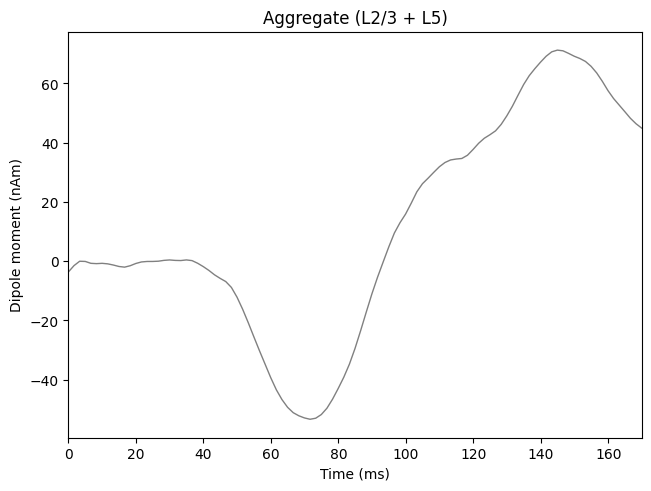

In [15]:
_ = threshold_experimental_dpl.plot()

You can see that the built-in plot method is assuming that the units of time are in miliseconds, and that the units of the current dipole are in nAm. The data plotted are for the Aggregate dipole, which is the sum of the Layer 2/3 and Layer 5 dipoles. 

### Prepare the Default Network for Simulation

Remember that exogenous inputs (modelled as spike trains arriving at the proximal or distal locations in the network) are necessary to drive network activity.

However, the `jones_2009_model()` does not have external driving inputs by default. We can verify this by confirming the `external drives` data attribute is empty

In [16]:
print("Check if the `jones_2009_model` includes external drives ...")
if jones_2009_model().external_drives:
    print("   Existing drives found!")
else:
    print("   No drives found; `jones_2009_model().external_drives` is empty")

Check if the `jones_2009_model` includes external drives ...
   No drives found; `jones_2009_model().external_drives` is empty


We can add the default drives for simulating ERPs automatically using the `add_erp_drives_to_jones_model()` function we imported from `hnn_core.network_models`. (You can also manually add individual drives, and we will cover how to do so in a future section.)

Let's first check if there are an external drives already attached to our network object `net default`; if not, we'll add the drives using the aforementioned function. 

Lastly, we will inspect the drives attached to `net_default`. For simulating ERPs, we expect to see two proximal drives and one distal drive.  


In [17]:
# if there are no drives attached to the Network, then add them
if not net_default.external_drives:
    print("No existing drives found. Adding default external drives ... ")

    # add the default external drives for ERP simulation
    # note:
    #   the drives are added to the object **in place**, meaning we don't
    #   need to assign the output back to the `net_default` variable
    add_erp_drives_to_jones_model(net_default)

    print("The following drives were added:")
else:
    print("Existing drives found on the network object.")
    print("Printing existing drive names:")

for key in net_default.external_drives.keys():
    print(f"   {key}")

No existing drives found. Adding default external drives ... 
The following drives were added:
   evdist1
   evprox1
   evprox2


Next, let's check the arrival time of each drive. Remember that for ERPs, we expect an initial feedforward (proximal) input, followed by a feedback (distal) input, followed by a second feedforward (proximal) input. 

As discussed in the [Introduction and ERP Overview](https://jonescompneurolab.github.io/textbook/content/05_erps/erp_overview.html) page, this sequence of driving inputs was based on studying evoked potentials in animals using invasive recordings, and served as our starting point simulating human ERPs with HNN. 

Note that the `_NetworkDrive` object behaves like a dictionary, meaning we can access its contents using keys with the same syntax used for dictionaries.  

To get the mean arrival times, we need to access a value stored within the `dynamics` data attribute of each `_NetworkDrive` object. The `dynamics` attribute contains a dictionary of parameters, including the `mu` key, which stores the mean arrival time. Because `_NetworkDrive` objects behave like dictionaries, we can access this value using the nested key structure drive["dynamics"]["mu"].

In [18]:
# ----------------------------------------
# inspecting a single drive object
# ----------------------------------------
# let's first inspect a single external drive object to understand
# its structure

# we can create a pointer to the "evdist1" object like so
drive_key = "evdist1"
drive_object = net_default.external_drives[drive_key]

# as mentioned above, we'll be accessing the value of the "mu"
# parameter in the "dynamics" data dictionary.

# we can create pointers to these objects to make the printouts
# below more readable
drive_dynamics = drive_object["dynamics"]
mean_arrival = drive_dynamics["mu"]

# cleanly print out properties of the drive object
# ----------------------------------------
print(
    "# " + "=" * 40 + "\n",
    "# Examining one drive object in detail",
    "\n# " + "=" * 40 + "\n",
    sep="",
)

print(
    "# Investigate the `_NetworkDrive` object",
    "# " + "-" * 40,
    f"Drive type: {type(drive_object)}",
    f'Drive name: "{drive_object["name"]}"',
    f"Drive keys:\n\t{str(list(drive_object.keys()))}",
    "",
    f'# Examining the "dynamics" data attribute of the "{drive_key}" drive',
    "# " + "-" * 40,
    f"Attribute type: {type(drive_dynamics)}",
    f"Attrubute keys: {list(drive_dynamics.keys())}",
    "",
    sep="\n",
)

# ----------------------------------------
# inspect the value of "mu" for each drive
# ----------------------------------------

# now let's loop through each drive and print the
# value of "mu" (i.e., the mean arrival time)

print(
    "# " + "=" * 40 + "\n",
    '# Print each drive\'s "mu" parameter',
    "\n# " + "=" * 40 + "\n",
    sep="",
)

for key, drive_object in net_default.external_drives.items():
    mean_arrival = drive_object["dynamics"]["mu"]

    print(
        f'Mean arrival time for "{key}": {mean_arrival} ms',
        sep="\n",
    )

# ========================================
# Examining one drive object in detail
# ========================================

# Investigate the `_NetworkDrive` object
# ----------------------------------------
Drive type: <class 'hnn_core.network._NetworkDrive'>
Drive name: "evdist1"
Drive keys:
	['type', 'location', 'n_drive_cells', 'event_seed', 'conn_seed', 'dynamics', 'events', 'weights_ampa', 'weights_nmda', 'synaptic_delays', 'probability', 'name', 'target_types', 'cell_specific']

# Examining the "dynamics" data attribute of the "evdist1" drive
# ----------------------------------------
Attribute type: <class 'dict'>
Attrubute keys: ['mu', 'sigma', 'numspikes']

# ========================================
# Print each drive's "mu" parameter
# ========================================

Mean arrival time for "evdist1": 63.53 ms
Mean arrival time for "evprox1": 26.61 ms
Mean arrival time for "evprox2": 137.12 ms


We can see that the drives we added do follow the expected sequence: a proximal drive arriving first at ~27 ms, a distal drive arriving second at ~64 ms, and a second proximal drive arriving last at ~ 137 ms.

Now that we've added the external drives to the `Network`, we are nearly ready to run our simulation of the threshold-level ERP.

### Run the Default Simulation

Before running the simulation, we need to choose a backend. HNN-core supports both the Joblib backend (which can run independent simulation trials in parallel), and the MPI backend (which can distribute the computation of a single simulation trial across multiple processes)

You can try running the simulation with both Joblib and MPI and compare the simulation speeds by changing the `use_MPI` flag below from False to True, or vice versa

Additionally, you should set the number of cores to use based on your machine's resources. There are instructions on how to check the number of available cores on the [Installation](https://jonescompneurolab.github.io/textbook/content/01_getting_started/installation.html) page. 

In [19]:
# choose a backend, and select the number of cores
# --------------------------------------------------
# try changing the use_MPI flag and comparing
# the simulation speeds
use_MPI = True

# note that `chosen_backend` here is a *pointer* variable,
# meaning it simply *points* to the backend that we assign
# in the if-else block below
if use_MPI is False:
    chosen_backend = JoblibBackend
else:
    chosen_backend = MPIBackend

# when calling our `chosen_backend` below, we can
# explicitly set the number of cores to use
manual_ncores = 4

# alternatively, we can use `psutil.cpu_count()` to
# automatically determine the number of available cores
import psutil  # noqa

auto_ncores = psutil.cpu_count(logical=False) - 1

# note that, in general, more cores = faster simulations
# however, there are diminishing returns. We'll use the
# lower number of cores since we we're not running
# computationally-demanding simulations in these tutorials
ncores = min(manual_ncores, auto_ncores)
print(
    f"Using {ncores} of {auto_ncores} available cores",
)

Using 4 of 13 available cores


The `simulate_dipole()` function below is the main function for generating simulated dipole signals from a `Network` object. It has two required arguments:

  1. the `Network` object

  2. the simulation duration (specified in ms)

The function accepts additional simulation parameters, including the integration timestep, the number of trials, and more

Once we've selected a backend, set the number of cores, and specified our required (and optional) simulation parameters, we're finally ready to run the default simulation for the threshold-level ERP

Note the syntax used to simulate the `Network` below. We use a `with` statement to run the simulation using the selected parallel backend (stored in `chosen_backend` in this case). The `simulate_dipole()` function is called inside this block, and the resulting output is assigned to the variable `dipoles_list`.

When we run the simulation below, `hnn-core` computes the cell and circuit activity, calculates the current dipoles, and returns a list of `Dipole` objects (one per each trial).


In [20]:
# set additional simulation parameters
# --------------------------------------------------
tstop = 170.0  # length of the simulation
dt = 0.025  # integration timestep
n_trials = 1  # number of trials

# run the simulation
# --------------------------------------------------
with chosen_backend(ncores):
    dipoles_list = simulate_dipole(
        net=net_default,
        tstop=tstop,
        n_trials=n_trials,
        dt=dt,
    )
# mod_shrink_output

MPI will run 1 trial(s) sequentially by distributing network neurons over 4 processes.
/opt/homebrew/Caskroom/miniconda/base/envs/dev/bin/nrniv:10: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  from pkg_resources import working_set
/opt/homebrew/Caskroom/miniconda/base/envs/dev/bin/nrniv:10: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  from pkg_resources import working_set
/opt/homebrew/Caskroom/miniconda/base/envs/dev/bin/nrniv:10: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  from pkg_resources import working_set
/opt/homebrew/Caskroom/miniconda/base/envs/dev/bin/nrniv:10: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  from pkg_resources import working_set
numprocs=4
Loading custom mechani

### Plot Default Simulation with Data

The simulation we just ran yields a dipole signal in units of nanoampere-meters (nAm). Remember that source-localize MEG and EEG data yield dipole signals in these same units of nAm. By representing the simulation and the experimental data in the same units, HNN enables a one-to-one comparison between the two signals.

Next, let's plot the experimental data alongside the simulated dipole output and compare the two signals directly.

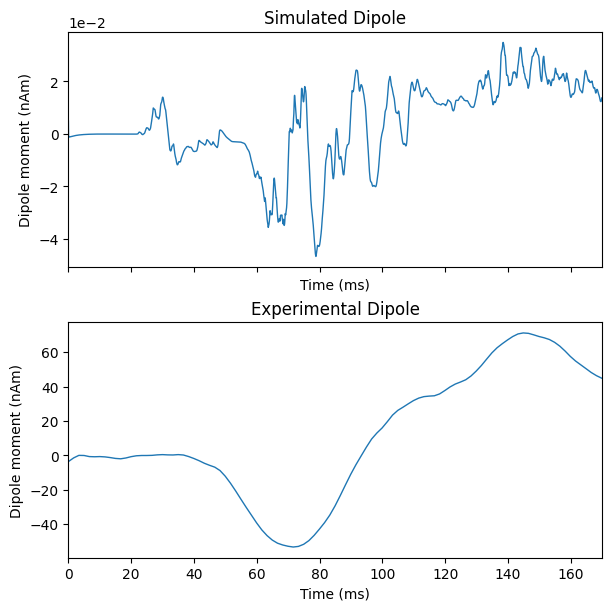

In [21]:
fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    sharex=True,
    figsize=(6, 6),
    constrained_layout=True,
)

_ = plot_dipole(
    dipoles_list,
    ax=axes[0],
    layer="agg",
    color="#1f77b4",
    show=False,
)

_ = threshold_experimental_dpl.plot(
    ax=axes[1],
    show=False,
)

# style figure
# --------------------------------------------------
# set line colors to match the accompanying GUI video
for subplot in axes:
    subplot.lines[0].set_color("#1f77b4")

# add subplot titles
axes[0].set_title("Simulated Dipole")
axes[1].set_title("Experimental Dipole");


You should note that the simulated dipole signal and the loaded data look quite different in both their shapes and their magnitudes. 

These discrepancies are due to the fact that `simulate_dipole()` returns a list of **raw** dipole signals. There are some post-processing steps we need to follow before we can truly compare our simulated and experimental dipoles, and we will discuss these steps in the next section. 

# Textbook Section 4.6

## Simulation Scaling and Smoothing in the API

Since we'll be plotting multiple figures in this section, let's define a color dictionary so that we can reuse colors without needing to manually specify the hexicecimal code every time we plot something. We'll try to use colors that mimic what is used in the HNN GUI video (above), though note that the GUI is more restrictive than the API and so there will be some discrepancies. 

In [22]:
gui_colors = {
    "orange": "#ff7f0e",
    "blue": "#1f77b4",
}

In the previous section, we ended with a plot of the raw simulated dipole and the loaded experimental dipole, which were different in both their shapes and magnitudes. 

These discrepancies are related to **Step 3** of our experimental workflow:

  3. **Adjust the scaling (and smoothing) of your simulated dipole signal**

With HNN, we simulate a network comprised of two 10 x 10 grids of pyramidal neurons, in two distinct cortical layers, for a total of 200 pyramidal neurons that contribute directly to the simulated dipole signal. (There are also 35 interneurons per layer, but these do not contribute *directly* to the dipole signal.) 

The human cortex, however, contains *many* more pyramidal neurons than in our reduced network, and source-localized MEG signals typically represent the synchronous activity of tens of thousands of pyramidal neurons.

Rather than explicitly simulate thousands of neurons, we can leverage the fact that the neocortex has a highly stereotyped, canonical circuit architecture. As such, the activity generated by a relatively small cortical column can be viewed as representative of the *synchronous* activity in a larger patch of cortex, and it is precisely this synchronous activity that we observe in our source-localized, experimental ERP data.

In the model, we represent this synchrony by multiplying our simulated dipole signal by a **uniform scaling factor**, which effectively captures the synchronous activity of a larger population of similarly-active neurons

We do this in `hnn-core` by using the `.scale()` method of the `Dipole` object.

Remember that the `simulate_dipole()` function returns a list of dipole objects, one for each trial. We need to first select an individual trial to apply the dipole scaling factor. 

In [23]:
# get the first (in this case, only) trial from the
# list of dipole objects
dipole_01 = dipoles_list[0]

Keep in mind that the scaling factor is applies to the object **in place** (in otherwords, the new dipole with the scaling applied will "overwrite" the raw, unscaled dipole)

Let's make a copy of the dipole object before we apply the scaling factor so we can plot both dipoles

In [24]:
# we use copy() to ensure we have a new copy of the dipole
# that is seprate from the original
dipole_01_scaled = dipole_01.copy()

# set scaling factor and apply it to the copy only
scaling_factor = 3000
dipole_01_scaled.scale(scaling_factor);

Note that we multiply the simulated dipole by a **uniform** scaling factor at each time point such that we are not altering the underlying shape of the signal, *only* the magnitude of the peaks and troughs. This ensure we are not overfitting to the experimental data, as fitting the scaling factor to any one peak *necessarily* changes the value every other time point.

We can see that this is the case when plotting the unscaled and scaled dipoles side by side. Note that the y axes (highlighted in red) are different, but the underlying waveform shapes (relative peaks and troughs) remain the same

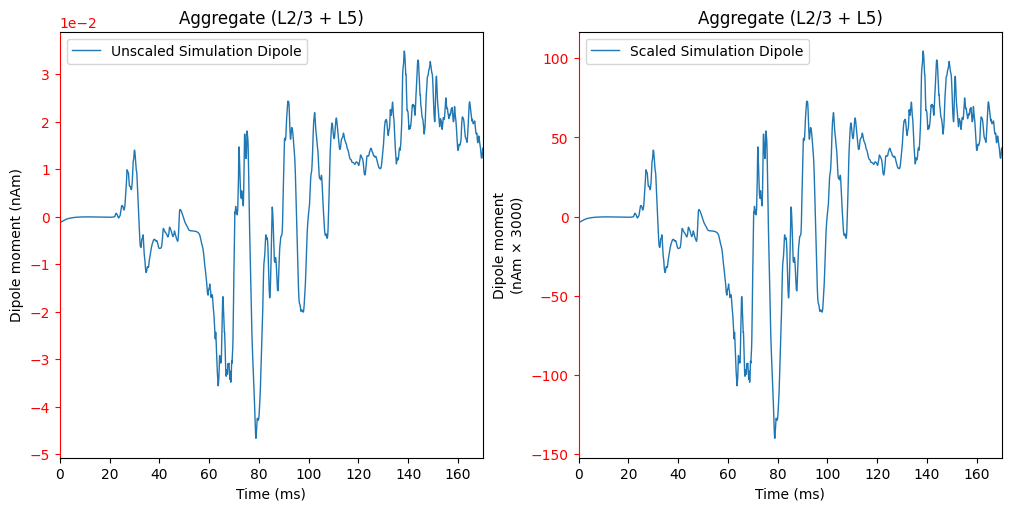

In [25]:
# plot the dipoles side by side
# --------------------------------------------------
fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(10, 5),
    constrained_layout=True,
)

_ = dipole_01.plot(
    ax=axes[0],
    show=False,
)
axes[0].lines[0].set_label("Unscaled Simulation Dipole")

_ = dipole_01_scaled.plot(
    ax=axes[1],
    show=False,
)
axes[1].lines[0].set_label("Scaled Simulation Dipole")

# style subplots
# --------------------------------------------------
for subplot in axes:
    # highlight y axes in red
    subplot.spines["left"].set_color("red")
    subplot.tick_params(
        axis="y",
        colors="red",
    )

    # change line colors
    subplot.lines[0].set_color(gui_colors["blue"])

    # show legends
    subplot.legend()

We can add the experimental data to these plots to compare the order of magnitude and see if our scaling factor was appropriate 

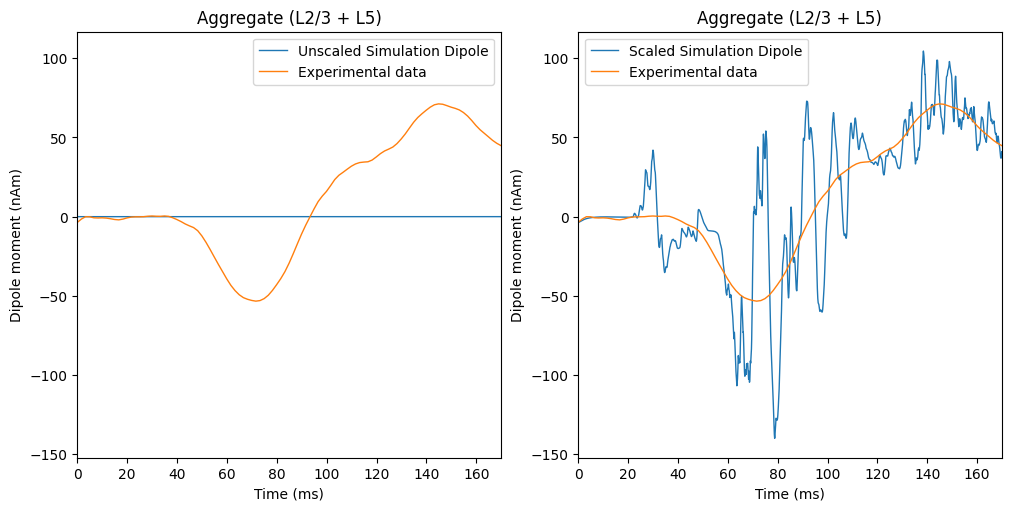

In [26]:
# conditionally add experimental data to our figure
# --------------------------------------------------
for subplot in axes:
    # if there's only one line on the plot, we still
    # need to add the experimental data
    if len(subplot.lines) == 1:
        # add experimental data
        _ = threshold_experimental_dpl.plot(ax=subplot, color="black")

        # change presentation
        subplot.lines[1].set_color(gui_colors["orange"])
        subplot.lines[1].set_label("Experimental data")
        subplot.legend()

# force y axes to be equal and reset their colors
# --------------------------------------------------
ymin = min(ax.get_ylim()[0] for ax in axes)
ymax = max(ax.get_ylim()[1] for ax in axes)

for subplot in axes:
    # apply the ymin and ymax
    subplot.set_ylim(ymin=ymin, ymax=ymax)

    # reset axis color
    subplot.spines["left"].set_color("black")
    subplot.tick_params(axis="y", colors="black")

fig

While the scaled simulation dipole is much closer to the order of magnitude of the experimental dipole, the signals themselves still differ substantially in their waveform shapes. 

This is because source-localized signals reflect the aggregate activity of a very large population of neurons. When a large number of neurons contribute synchronously to the measured signal, small differences in their individual spike timing tend to be averaged out, producing a "smoother" dipole signal than we obtain from our smaller simulated network.

To approximate this effect, we can use the `.smooth()` method of the `Dipole` object, which applies a Hamming-windowed convolution to the simulated dipole. The width of this convolution window is specified in milliseconds, allowing you to control the amount of smoothing applied to the signal.

Note that the `.smooth()` method also updates the dipole *in place*, so we will first make a copy of the object before the transformation. Below, we will plot updated dipoles using two different window widths for comparison.

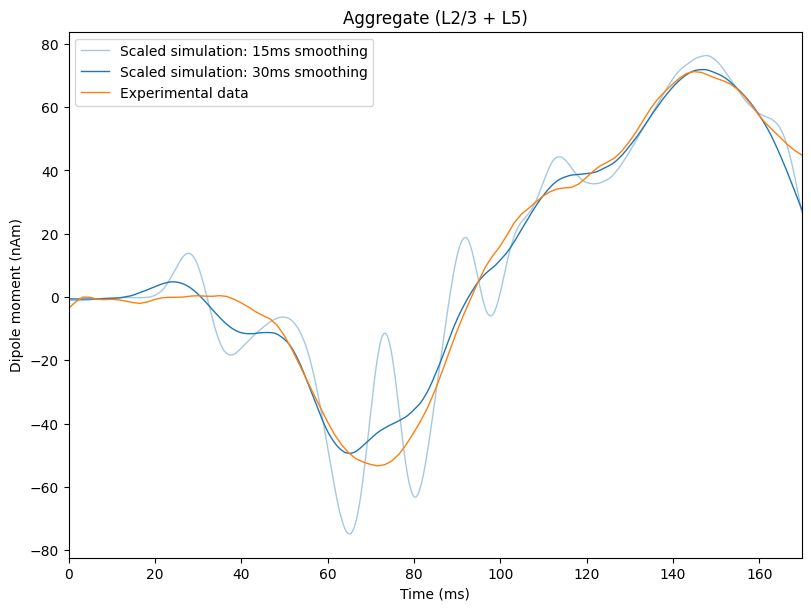

In [27]:
fig, ax = plt.subplots(
    figsize=(8, 6),
    constrained_layout=True,
)

# plot scaled dipole with 15ms window
# --------------------------------------------------
dipole_15ms = dipole_01_scaled.copy().smooth(15)

_ = plot_dipole(
    dipole_15ms,
    ax=ax,
    show=False,
)

# pro tip: "[-1]" here targets the newly-added line
ax.lines[-1].set_color(gui_colors["blue"])
ax.lines[-1].set_alpha(0.4)  # reduce the opacity to 40%
ax.lines[-1].set_label("Scaled simulation: 15ms smoothing")

# plot scaled dipole with 30ms window
# --------------------------------------------------
dipole_30ms = dipole_01_scaled.copy().smooth(30)

_ = plot_dipole(
    dipole_30ms,
    ax=ax,
    show=False,
)

ax.lines[-1].set_color(gui_colors["blue"])
ax.lines[-1].set_label("Scaled simulation: 30ms smoothing")

# plot experimental data
# --------------------------------------------------
_ = threshold_experimental_dpl.plot(
    ax=ax,
    show=False,
)

ax.lines[-1].set_label("Experimental data")
ax.lines[-1].set_color(gui_colors["orange"])

plt.legend()

We can see that the fit is considerably improved after applying the smoothing to the simulation. 

Lastly, it is important to note that the scaling factor also gives us an estimate of the number of synchronous neurons that contributed to our experimental dipole signal.

For example, if the M70 peak in our our experimental data is approximately -60 nAm, and the raw simulated dipole signal is approximately -0.02 nAm, then we would need to multiply the simulated dipole by 3,000 to bring the signals into the same order of magnitude. In this case, we would estimate that approximately 3,000 x 200 = 600,000 pyramidal neurons are contributing to the signal in the *experimental* data. 

While we've found that a scaling factor of 3,000 and a smoothing window of 30 work well for the experimental MEG data in Jones et al. 2007, there is no guarantee that these will be appropriate for your experimental data. In fact, it is very likely that you will need to try different scaling factors and smoothing windows to bring your simulation and your data into the same order of magnitude. 

# Textbook Section 4.7.1

## Multiscale Interpretation, Part 1

The next step in our experimental workflow is **Step 4**: hand tune the model parameters to improve the fit between your experimental data and your simulations

However, rather than immediately jump into the hand-tuning process, we will first examine how the `External Drives` interact with the local network in our simulations. The goal of these exercises is to help you build critical analysis skills that provide the foundation for interpreting and eventually tuning simulations to your own experimental data.

Thus far, we have only compared the loaded experimental data to the aggregate dipole from our simulation. But in order to better understand the ***generators*** of our data, we need to consider more than just the aggregate dipole. We need to examine the cell and circuit activity that ***underlies*** our signals. 

The power of the HNN model is that it allows us to "peek inside" the simulated network and examine the cell- and circuit-level activity, such as the layer-specific dipoles, cell-specific spiking, local field potentials, and more. These are data that are often not readily accessible to researchers using standard MEG/EEG experimental paradigms with human subjects, unless the MEG/EEG recordings are accompanied by an invasive recording modality.  

In this page (Part 1), we will focus on multiscale interpretation of the underlying network activity around the time of the first *proximal* drive. In the next page (Part 2), we will repeat the same exercise for the time around the first *distal* drive.

We will begin by making a new figure that more closely matches the standard GUI output, so that the ***interpretation*** of the figures matches what is said in the accompanying video. We will generate a figure that shows:

  1. A histogram of spikes from the `External Drives`

  2. The scaled and smoothed dipole from the `default` simulation

  3. The loaded experimental data

In order to get a 1-to-1 match with the standard GUI output, we will also need to re-simulate the default network. The reason for this is that the GUI and the Python API initialize the `default` evoked drives with different `seed` (a.k.a. random number generator) values. 

Since we want to match the GUI outputs ***as closely as possible***, we need to use the same `seed` values. 

Previously, we loaded the Evoked Drives using the `add_erp_drives_to_jones_model()` function. For this example, we will apply the drives from the exact `.json` configuration file used by the GUI. The ***only*** parameters that differ are the "event_seed" for each drive. 

In [28]:
gui_default_url = (
    "https://raw.githubusercontent.com/jonescompneurolab/hnn-data/refs/heads/main/tutorial_networks/gui_defaults.json"
)
urlretrieve(
    gui_default_url,
    "gui_default.json",
);

We can then use the `read_network_configuration` function to load the file. Note that you can also save the network configuration file directly from the GUI to your local machine, and you can load the drives directly from your machine using the same function.

In [29]:
from hnn_core import read_network_configuration  # noqa

net_default_gui = read_network_configuration("gui_default.json")

We will then "re-simulate" the network, and apply the smoothing and scaling factors exactly as we did in the previous section. 

In [30]:
# Remember that you need to select a backend and set the number
# of cores that is appropriate for your machine, as we did
# above in the "Simulate Default Network" section

# check the backend/number of cores we selected above
# --------------------------------------------------
print(
    f"Selected backend: {chosen_backend}",
    f" Number of cores: {ncores}",
    "\n" + "-" * 50 + "\n",
    sep="\n",
)

# re-run the simulation with the updated seed values
# --------------------------------------------------
with chosen_backend(ncores):
    gui_dipoles_list = simulate_dipole(
        net=net_default_gui,
        tstop=tstop,
        n_trials=n_trials,
        dt=dt,
    )

# apply the same scaling/smoothing that we used above
# --------------------------------------------------
processed_dipole = gui_dipoles_list[0].copy()
processed_dipole.scale(3000).smooth(30);

# mod_shrink_output

Selected backend: <class 'hnn_core.parallel_backends.MPIBackend'>
 Number of cores: 4

--------------------------------------------------

MPI will run 1 trial(s) sequentially by distributing network neurons over 4 processes.
/opt/homebrew/Caskroom/miniconda/base/envs/dev/bin/nrniv:10: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  from pkg_resources import working_set
/opt/homebrew/Caskroom/miniconda/base/envs/dev/bin/nrniv:10: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  from pkg_resources import working_set
/opt/homebrew/Caskroom/miniconda/base/envs/dev/bin/nrniv:10: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  from pkg_resources import working_set
/opt/homebrew/Caskroom/miniconda/base/envs/dev/bin/nrniv:10: DeprecationWarning: pkg_resources is deprecated as an

Next, we will create our new, combined figure that matches the initial GUI output. Since we will be re-generating this plot numerous times throughout the rest of the ERP walkthrough, we will create a plotting function called `plot_initial_gui_figure` that accepts three arguments:

  1. The network object

  2. The processed simulation dipole

  3. The experimental dipole

Writing a function to generate this plot will allow us to re-use this same code later with different arguments, which will reduce the amount of code we need to repeat later.

The first subplot in our figure will show the histogram of spikes from the `External Drives`. Remember that we model the `External Drives` as multiple series of exogenous spikes arriving as inputs to either the proximal or distal locations in the network, as shown in the diagrams below:

##### Figure 7.1.A: Template Network Model
![](https://raw.githubusercontent.com/jonescompneurolab/jones-website/refs/heads/master/images/textbook/content/05_erps/full_network_model.png)

Spikes for *all* cell types can be found in the `net.cell_response.spike_times_by_type` data dictionary, with the dictionary's keys corresponding to either the unique `cell_types` name or the unique `external_drives` name.

For example, in the code block below, we print the first and last spike from each drive

In [31]:
trial = 0

# we can get the drives programatically, but in an *unordered*
# list, with the line below
all_drives = list(net_default_gui.external_drives.keys())

# instead, I'll specify them manually by order of arrival time
all_drives = ["evprox1", "evdist1", "evprox2"]

# the object below includes *all* cell spikes, not just for drives
all_spike_types = net_default_gui.cell_response.spike_times_by_type

# print the first and last spike to arrive at the network for
# each external drive
for drive in all_drives:
    first_spike = round(min(all_spike_types[drive][trial]), 3)
    last_spike = round(max(all_spike_types[drive][trial]), 3)
    print(f'Drive = "{drive}":')
    print(
        f"    First spike arrival time: {first_spike} ms",
        f"     Last spike arrival time: {last_spike} ms",
        "",
        sep="\n",
    )

Drive = "evprox1":
    First spike arrival time: 19.214 ms
     Last spike arrival time: 34.407 ms

Drive = "evdist1":
    First spike arrival time: 54.571 ms
     Last spike arrival time: 75.721 ms

Drive = "evprox2":
    First spike arrival time: 110.021 ms
     Last spike arrival time: 158.814 ms



To visualize the spike arrival times for all of the `External drives`, we can use the built-in `plot_spikes_hist()` method in the network's `CellResponse` object. This method will generate a histogram of the arrival times of the spikes at the network, which we will use to examine the relationship between the driving inputs and the simulated response.

Note that, in the code below, we "wrap" `plot_spikes_hist` in a custom function called `custom_drive_hist`. The reason we do this is to create a version of the template `plot_spikes_hist` figure with *pre-configured arguments*, allowing us to easily generate a custom version of the plot later on without repeating the same code. 

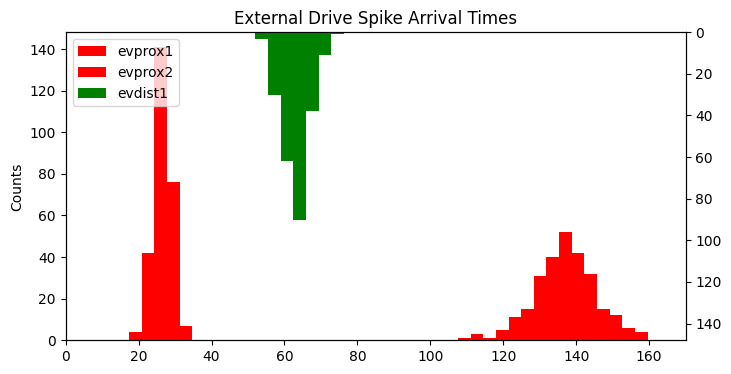

In [32]:
# initialize the figure
fig, ax = plt.subplots(figsize=(8, 4))


# define a function to customize the input histogram
def custom_drive_hist(
    ax,
    net,
):
    _ = net.cell_response.plot_spikes_hist(
        ax=ax,
        invert_spike_types=["evdist1"],  # "flip" the y axis
        color={
            "evprox1": "r",
            "evdist1": "g",
            "evprox2": "r",
        },
        show=False,
    )
    ax.set_title("External Drive Spike Arrival Times")

    return


# plot the histogram using our custom function
custom_drive_hist(
    ax=ax,
    net=net_default_gui,
)

Note that the distal drive ("evdist1") is plotted on the secondary (right-most) y axis, which is *inverted*. We do this to emphasize the scientific point that distal depolarization is one of the drivers of what we call **Inward Currents** (see the Figure B below), meaning current that flows "***down***" the long, apical dendrites of the pyramidal neurons (i.e., ***down*** towards the ***infragranular*** layers of the cortex).

##### Figure 7.1.B: Inward and Outward Currents

![](https://raw.githubusercontent.com/jonescompneurolab/jones-website/refs/heads/master/images/textbook/content/05_erps/inward_outward_currents.png)

To replicate the initial GUI figure, we will need to combine the histogram with a plot of the simulated and experimental dipoles. Let's create another "wrapper" function that generates a custom implementation of the template dipole plot. 

The code within the function below largely overlaps with our previously-used plotting code. The only new addition is the inclusion of the Root Mean Squared Error ("RMSE") in the dipole plot, which relies on the `_rmse` helper function from `hnn_core.dipole`

In [33]:
def plot_sim_exp_dipoles(
    ax,
    processed_dipole,
    experimental_dpl,
    sim_name=None,
):
    from hnn_core.dipole import _rmse  # noqa

    # plot simulation and data in the bottom subplot
    # --------------------------------------------------
    _ = plot_dipole(
        processed_dipole,
        ax=ax,
        show=False,
    )
    ax.lines[-1].set_color(gui_colors["blue"])
    if sim_name is None:
        sim_name = "Simulation"
    ax.lines[-1].set_label(sim_name)

    # plot experimental data in the bottom subplot
    # --------------------------------------------------
    _ = experimental_dpl.plot(
        ax=ax,
        show=False,
    )
    ax.lines[-1].set_label("Experimental data")
    ax.lines[-1].set_color(gui_colors["orange"])

    # add RMSE to the figure
    # --------------------------------------------------
    t0 = 0.0
    tstop = processed_dipole.times[-1]
    rmse = _rmse(
        processed_dipole,
        experimental_dpl,
        t0,
        tstop,
    )

    ax.annotate(
        f"RMSE: {rmse:.4f}",
        xy=(0.95, 0.05),
        xycoords="axes fraction",
        ha="right",
        va="bottom",
        fontsize=12,
    )

    ax.legend()

    return


Lastly, we will create a function `plot_initial_gui_figure`, that ***combines*** our two plotting functions to generate our combined GUI figure. 

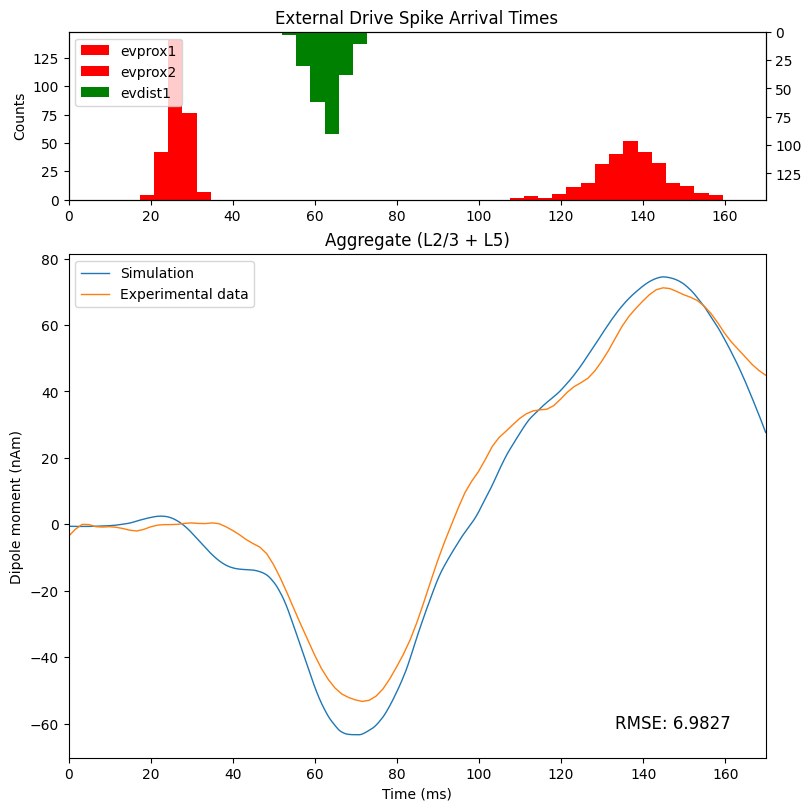

In [34]:
def plot_initial_gui_figure(
    net,
    processed_dipole,
    experimental_dpl,
    sim_name=None,
):
    fig, axes = plt.subplots(
        nrows=2,
        figsize=(8, 8),
        gridspec_kw={"height_ratios": [1, 3]},  # sets subplot dimensions
        constrained_layout=True,
    )

    # plot the input histogram in the top subplot
    # --------------------------------------------------
    custom_drive_hist(
        ax=axes[0],
        net=net,
    )

    # plot the dipoles in the bottom subplot
    # --------------------------------------------------
    plot_sim_exp_dipoles(
        axes[1],
        processed_dipole,
        experimental_dpl,
        sim_name,
    )

    return fig


_ = plot_initial_gui_figure(
    net_default_gui,
    processed_dipole,
    threshold_experimental_dpl,
)

Now that we have replicated the initial GUI output, we can move on to interpretation. In this Python API tutorial, we will briefly highlight some key insights, but please watch the accompanying GUI video tutorial for a more detailed walkthrough.

As a reminder, here we will focus on unpacking the dynamics that are responsible for generating our aggregate, simulated signal around the time of the first proximal drive.

We know from our outputs above that the first spike from the first proximal drive ("evprox1") arrives at the network just after 19ms, and the first spike from the first distal drive ("evdist1) arrives just after 54ms.

Given that the network is initially at rest and no other inputs arrive during this time period, any changes in the simulation output between those two timepoints can be isolated to the impact of the first proximal drive on the network.

We've previously told you that proximal drives generally cause what we refer to as **"Outward Currents"** (see the Figure B), i.e. current that flows towards the *supragranular* layers of the cortex in the long, apical dendrites of our pyramidal neurons. 

However, if we examine the time period of interest, we see that this assertion does not hold true for the default network. While there is an initial positive deflection in the simulation dipole (blue line), the signal actually reverses direction and drops *below* zero, indicating net current flow towards the *infragranular* layers.

To highlight this observation, the code below adds an outline to the time window of interest and also a dashed line at `y = 0`. We will once again implement this feature as a function so that we can re-use it later on. (It is not important to understand how this function works.)

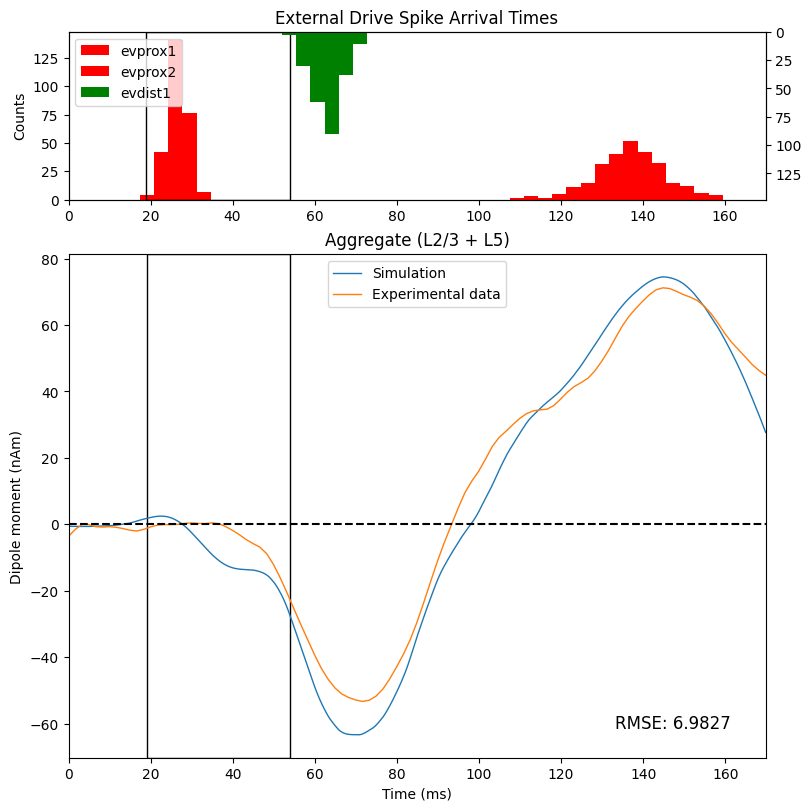

In [35]:
# create a function to add an outline around a time window
# --------------------------------------------------
def add_outline_to_subplot(
    ax,
    x_bounds=[19, 54],
    show_origin_line=True,
):
    from matplotlib.patches import Rectangle  # noqa

    # set x and y boundaries for the outline/rectangle
    xmin, xmax = x_bounds[0], x_bounds[1]
    ymin, ymax = ax.get_ylim()

    # add a rectangle to each subplot
    ax.add_patch(
        Rectangle(
            xy=(xmin, ymin),  # start position
            width=xmax - xmin,
            height=ymax - ymin,
            fill=False,
        )
    )

    # optionally add dashed horizontal line at the origin
    if show_origin_line:
        ax.axhline(
            linestyle="--",
            color="black",
        )
    return


# re-generate and update figure with the outlines
# --------------------------------------------------
fig = plot_initial_gui_figure(
    net_default_gui,
    processed_dipole,
    threshold_experimental_dpl,
)
add_outline_to_subplot(
    fig.axes[0],
    show_origin_line=False,
)
add_outline_to_subplot(fig.axes[1])

So, why might it be the case that the net current flow during this time window is *inward*? To begin to unpack this, we need to look at what's happening in the underlying circuits.

We can start by looking at the layer-specific dipoles, as done in the code below.

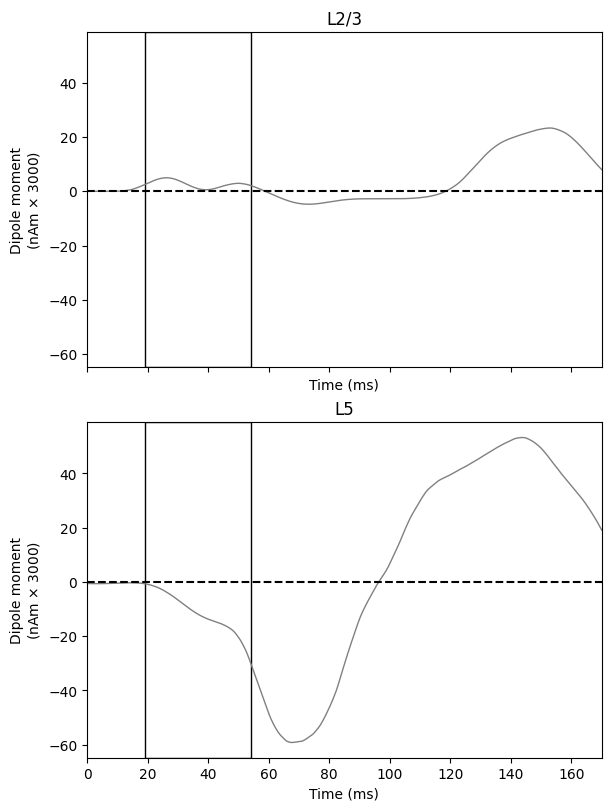

In [36]:
# initialize figure and plot layer-specific dipoles
# --------------------------------------------------
fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    sharex=True,
    figsize=(6, 8),
    constrained_layout=True,
    sharey=True,
)

for idx, layer in enumerate(["L2", "L5"]):
    plot_dipole(
        processed_dipole,
        ax=axes[idx],
        layer=layer,
        show=False,
    )

# add outline around first proximal drive
# --------------------------------------------------
for ax in fig.axes:
    add_outline_to_subplot(ax)

These figures clearly indicate that the net *inward* current in the aggregate dipole (which is simply the sum of the Layer 2/3 and Layer 5 dipoles) in this time window is being driven by Layer 5.

Next, let's examine the spiking in the local network, paying particular attention to what is happening in Layer 5 that may explain the effect. 

We can use the `plot_spikes_raster()` method of the `CellResponse` object to generate a raster plot that shows not only the cell-type-specific spiking, but also overlays the layer-specific dipoles over the corresponding pyramidal neurons that contribute to those signals. (Note that the layer-specific dipoles are shifted along the y-axis to overlay the appropriate spiking cells, but their scaling remains unchanged from the figure above.)

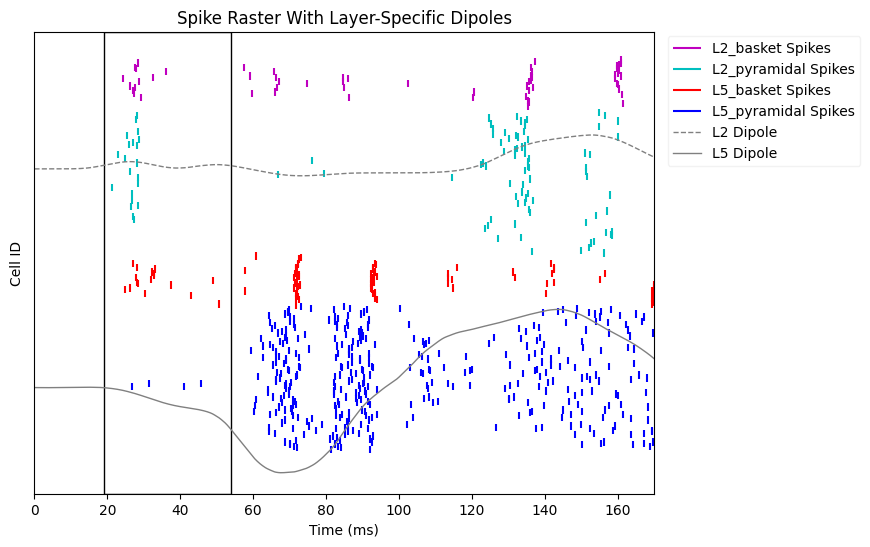

In [37]:
# initialize the figure and generate the raster plot
# --------------------------------------------------
fig, axes = plt.subplots(figsize=(8, 6))


def custom_spikes_raster(
    ax,
    net,
    processed_dipole,
):
    _ = net.cell_response.plot_spikes_raster(
        ax=ax,
        dpl=processed_dipole,
        overlay_dipoles=True,
        show=False,
    )
    ax.set_title("Spike Raster With Layer-Specific Dipoles")

    # move legend outside figure to not overlap plot
    # --------------------------------------------------
    legend = ax.get_legend()
    ax.artists[-1].remove()
    legend.set_bbox_to_anchor((1.01, 0.85))
    legend.set_loc("center left")

    return


custom_spikes_raster(
    ax=axes,
    net=net_default_gui,
    processed_dipole=processed_dipole,
)

# add outline around first proximal drive
# --------------------------------------------------
add_outline_to_subplot(
    axes,
    show_origin_line=False,
)

With this figure, we could begin to relate the cell-specific spiking to the layer-specific dipoles. 

However, the smoothed dipole we plot in the figure above obscures the dynamic relationship between the cell spiking and the dipole. Typically, when doing this type of multi-scale interpretation, we want to look at the *unsmoothed* dipole in relation to the spiking

Below, we will re-copy the raw dipole, and apply *only* the scaling factor. We will then re-plot the spike raster with the unsmoothed dipole.

We can also add the drives histogram as an additional subplot, so we can view several of the key data we need for interpretation in one single figure.

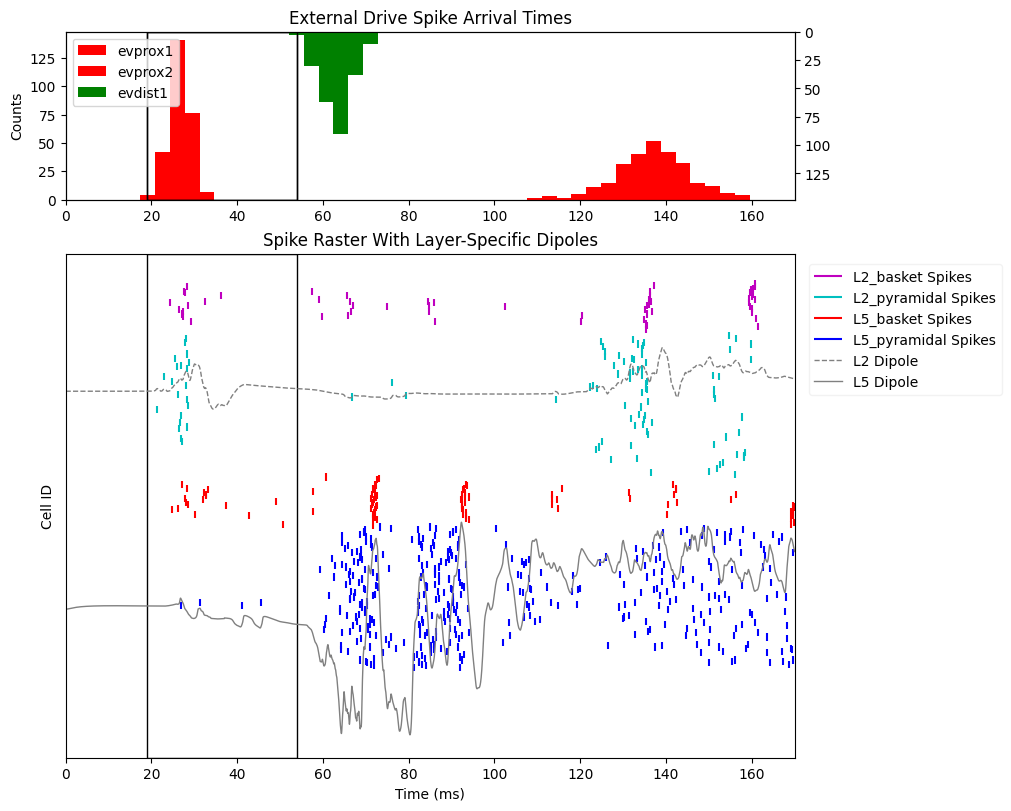

In [38]:
unsmoothed_dipole = gui_dipoles_list[0].copy()
unsmoothed_dipole.scale(3000)


def plot_combined_raster_hist(
    net,
    dipole,
):
    fig, axes = plt.subplots(
        nrows=2,
        figsize=(10, 8),
        gridspec_kw={"height_ratios": [1, 3]},  # sets subplot dimensions
        constrained_layout=True,
    )

    # plot the input histogram in the top subplot
    # --------------------------------------------------
    custom_drive_hist(
        ax=axes[0],
        net=net,
    )

    # plot the spike raster in the bottom subplot
    # --------------------------------------------------
    custom_spikes_raster(
        ax=axes[1],
        net=net,
        processed_dipole=dipole,
    )

    return fig


fig = plot_combined_raster_hist(
    dipole=unsmoothed_dipole,
    net=net_default_gui,
)

for ax in fig.axes:
    add_outline_to_subplot(
        ax,
        show_origin_line=False,
    )

Now we have all of the information we need to relate the cell-specific spiking to the layer-specific dipoles in a single plot. 

We will pick up from this point in the subsequent page, Part 2.

# Textbook Section 4.7.2

## First Proximal Drive (Contd...)

Continuing from where we left off in the previous section, we had just generated a new figure that shows the histogram of spikes for the external drives, the cell-specific spiking in the network, and the layer-specific dipoles without any smoothing. 

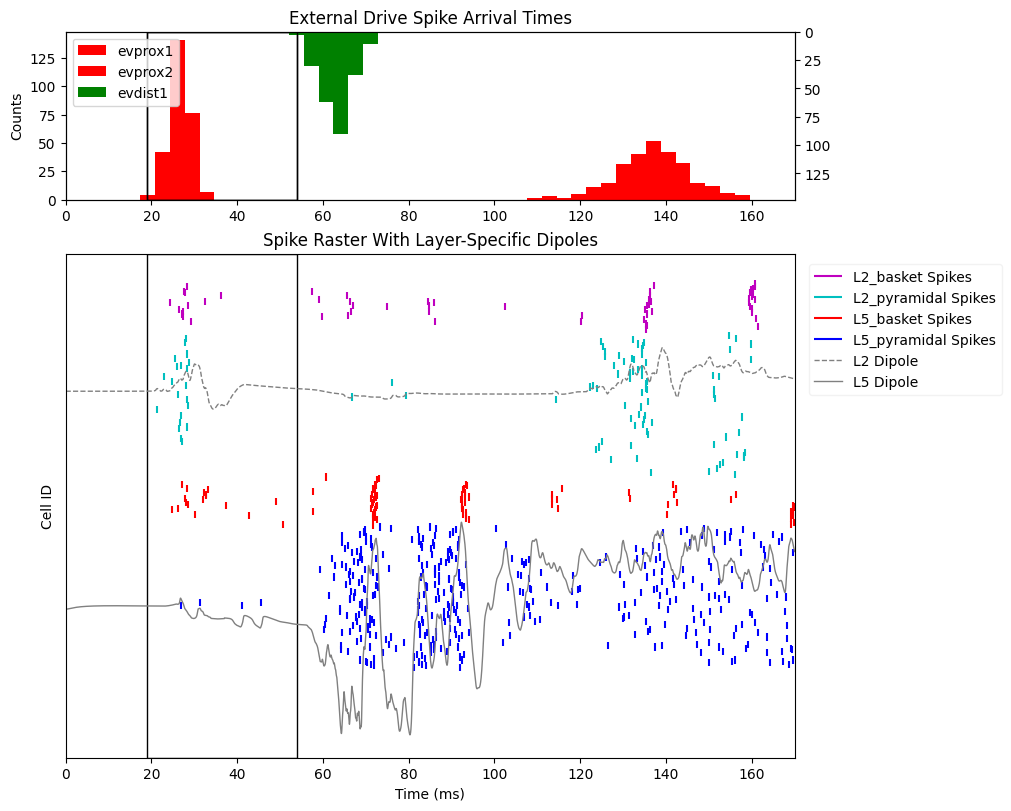

In [39]:
fig = plot_combined_raster_hist(
    dipole=unsmoothed_dipole,
    net=net_default_gui,
)

for ax in fig.axes:
    add_outline_to_subplot(
        ax,
        show_origin_line=False,
    )

From this figure, we can begin to unpack why the aggregate dipole shows a net *inward* current, despite our previous assertion that proximals drives generally cause *outward* current. 

We previously established from the layer-specific dipoles that the net *inward* current is largely dominated by Layer 5. Looking at the spiking for Layer 5, we see that the overall effect of this drive is that there is far more interneuron spiking than pyramidal neuron spiking.

In the Figure below, we see that one of the causes of Inward Currents is somatic hyperpolarization, which is caused by inhibitory connections on the pyramidal neurons from the interneurons.

##### Figure 7.2.A: Inward and Outward Currents
![Template Model Figure](https://raw.githubusercontent.com/jonescompneurolab/jones-website/refs/heads/master/images/textbook/content/05_erps/inward_outward_currents.png)

Our spiking raster plot suggests that the somatic hyperpolarization from the Layer 5 interneurons onto the pyramidal neurons is the dominant effect.

We do see that each pyramidal neuron spike is accompanied by a small positive deflection in the dipole. These positive deflections are a result of the ***backpropagating action potentials*** that occur when these neurons spike, and are one of our causes of *outward* currents.

All in all, this figure suggests that our proximal drive to Layer 5 is activating the interneurons much more strongly than the pyramidal neurons. We can examine the network parameters to see if this presumption holds true.

As we did previously, let's examine the drive object, this time looking at `evprox1`. We'll once again print the "keys" for the object so we can view all of its attributes.


In [40]:
# create a pointer variable for "evprox1"
evprox1 = net_default.external_drives["evprox1"]

# print the keys
print(
    "# Drive Object Keys",
    "# " + "-" * 40,
    list(evprox1.keys()),
    sep="\n",
)


# Drive Object Keys
# ----------------------------------------
['type', 'location', 'n_drive_cells', 'event_seed', 'conn_seed', 'dynamics', 'events', 'weights_ampa', 'weights_nmda', 'synaptic_delays', 'probability', 'name', 'target_types', 'cell_specific']


The attributes of interest to our question are `weights_ampa` and `weights_nmda`, which represent the excitatory synaptic connections (either AMPA or NMDA) between the proximal drive and the network. These attributes are data dictionaries with keys that correspond to the target celltype in the local network, and values that are the numerical weights for those connections.

In [41]:
# below, we set up a loop to print the keys and values
# for each of synapse types

synapse_types = ["weights_ampa", "weights_nmda"]

for synapse_weights in synapse_types:
    print(
        f"# {synapse_weights}",
        "# " + "-" * 40,
        sep="\n",
    )
    # check if the connections exist before trying to
    # loop through the data dictionary
    if evprox1[synapse_weights] is not None:
        # print the celltype and weight for each connection
        for celltype, weight in evprox1[synapse_weights].items():
            print(f"Celltype: {celltype}", f"    Weight: {weight}", "", sep="\n")
    # if the connection does not exist, print the value
    # of the data attribute, which will be None
    else:
        print(
            evprox1["weights_nmda"],
        )

# weights_ampa
# ----------------------------------------
Celltype: L2_basket
    Weight: 0.08831

Celltype: L2_pyramidal
    Weight: 0.01525

Celltype: L5_basket
    Weight: 0.19934

Celltype: L5_pyramidal
    Weight: 0.00865

# weights_nmda
# ----------------------------------------
None


We can see in the output above that there are no NMDA connections defined for this particular drive. Therefore, we need only examine the AMPA weights. 

Focusing on Layer 5, we see that the strength of the inputs to the interneurons (`L5_basket`) are over 20 times stronger than the strength of the weights to the pyramidal neurons (`L5_pyramidal`).

This supports our presumption above that this particular proximal drive to Layer 5 is activating the interneurons much more strongly than it is activating the pyramidal neurons.

## First Distal Drive


Next, we will examine the first distal drive using the same figures for interpretation. However, we'll change the outline to map onto the correct time window for the distal drive. We'll use the window from just before the distal drive's first spike arrives at the network to just before the *second* proximal drive's first spike arrives at the network.
Let's first use our custom plotting function `plot_initial_gui_figure` to re-generate the figure showing the aggregate dipole plotted against the experimental data.

It's important to note that the time window around the distal drive differs from the first proximal drive in that the network is *not* at its "resting state" when the distal drive first arrives at the network. Therefore, we cannot isolate changes in the simulated signal *exclusively* to the impact of the distal drive arriving at the network.

Nevertheless, we can see that there is a strong net *inward* current, which gradually weakens after the mean arrival time of the distal drive.

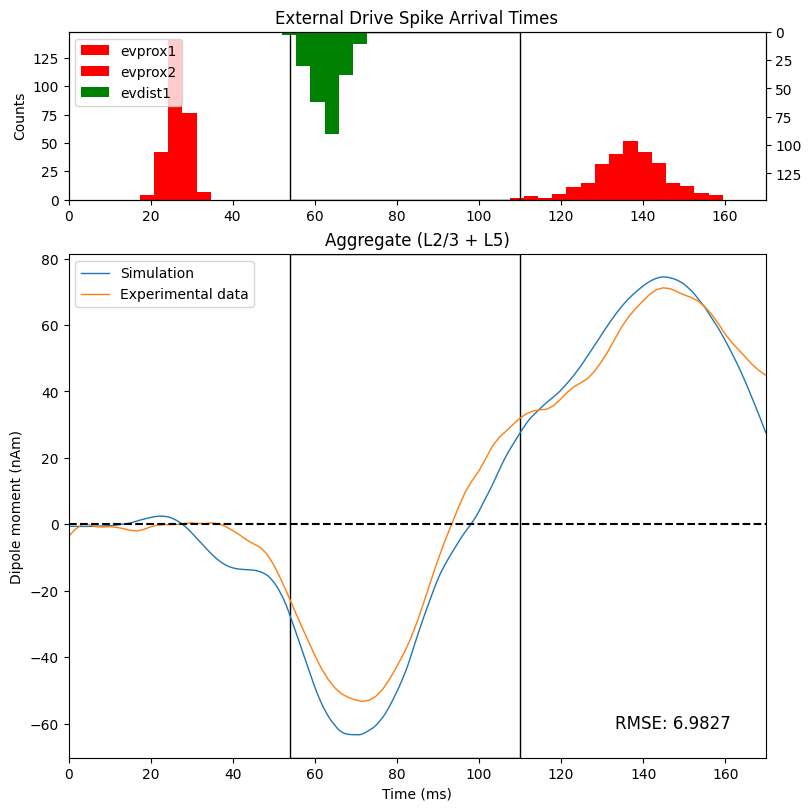

In [42]:
fig = plot_initial_gui_figure(
    net_default_gui,
    processed_dipole,
    threshold_experimental_dpl,
)

# note that, for each subplot, we manually set the time
# window used to draw the outline
add_outline_to_subplot(
    fig.axes[0],
    x_bounds=[54, 110],
    show_origin_line=False,
)
add_outline_to_subplot(
    fig.axes[1],
    x_bounds=[54, 110],
)

It's also noteworthy that the direction of the net current flow shifts to be *outward* (positive in absolute value) even *before* the second proximal drive's first spike arrives at the network. Let's look at our custom raster plot to investigate this observation further.

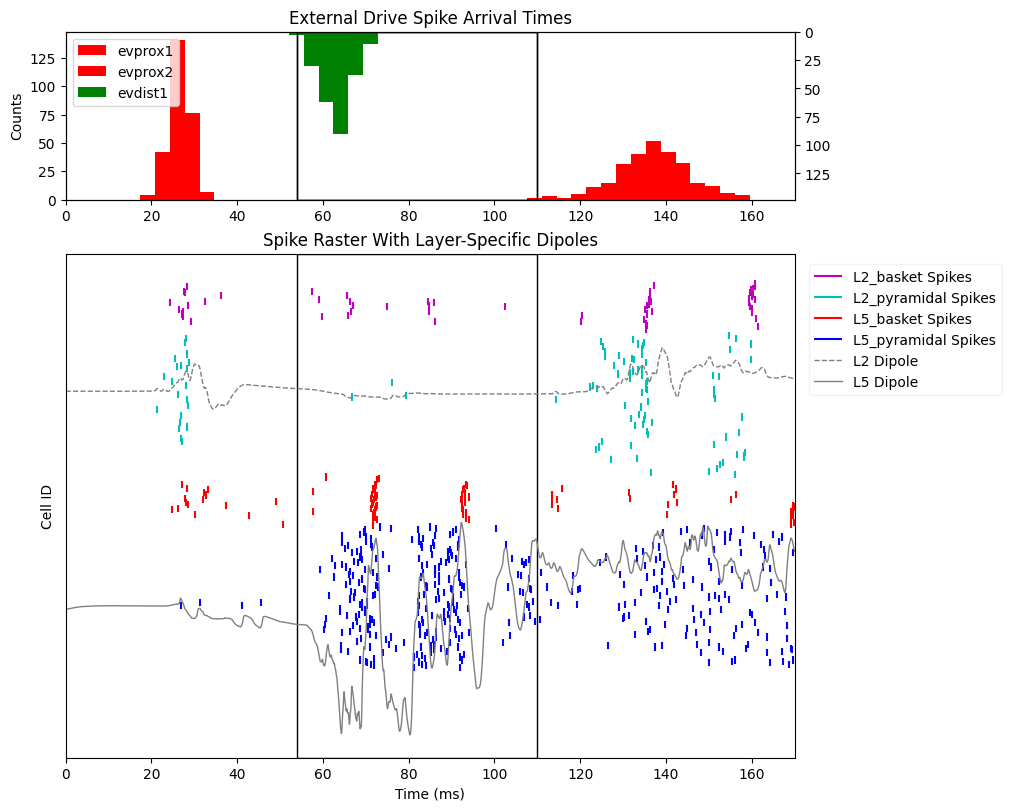

In [43]:
fig = plot_combined_raster_hist(
    dipole=unsmoothed_dipole,
    net=net_default_gui,
)

# as with the figure above, we manually specify
# the time window for the outline
for ax in fig.axes:
    add_outline_to_subplot(
        ax,
        x_bounds=[54, 110],
        show_origin_line=False,
    )

We see some different dynamics at play during this time window. We'll again focus our attention on Layer 5, since there's comparatively less happening in Layer 2/3 dipole around the distal drive. 

First of all, note that the initial and strong *inward* current in Layer 5 occurs during a period with comparatively few interneuron spikes. We can see in Figure A (above) that the distal drive depolarizes the most superficial apical dendrites of the pyramidal neurons. This distal depolarization is one of our causes of *inward currents*, and is driving the initial downward deflection seen in the Layer 5 dipole. 

By 60ms, we begin to observe some pyramidal neuron spiking. We can be reasonably confident that the pyramidal neuron spiking is not due to lingering effects of the first proximal drive, but rather to the activation of the *local* network.

When the distal drive creates a strong inward current, that current travels down the apical dendrites until it eventually reaches the soma. If the current at the soma is strong enough, it will cause the pyramidal neurons to spike, and the backpropagating action potentials create outward currents that compete against the inward currents from the distal depolarization. 

You can clearly see the competition between the inward and outward currents in the rapid positive and negative deflection in the dipole around the first plateau after the distal drive.   

However, the number of pyramidal neurons spiking continues to increase over time, and eventually the outward currents begin to dominate, leading to a fairly sharp rise in the dipole around 70ms. This continues until we see a highly synchronous bout of interneuron spiking. Given that the distal drive does *not* target the Layer 5 interneurons directly (as shown in the Template Figure), we can be reasonably sure that the interneuron spiking is mediated by the coupling in the local network between the pyramidal neurons and the interneurons. 

This recurrent inhibition in the local network not only prevents the pyramidal neurons from spiking for a time, briefly shutting down the outward currents from backpropagating action potentials, but also reinforces the inward currents from the distal drive by hyperpolarizing the pyramidal neuron somas.

After the pyramidal neurons are released from inhibition, they begin spiking again, and the same pattern repeats. 

Whereas the smooth dipole creates the illusion of a steady decline and subsequent rise the signal, the unsmoothed dipole clearly illustrates the recurrent "push-and-pull" dynamics between the pyramidal neurons and interneurons in the local network, as they work against each other to push current up and down the apical dendrites. 

# Textbook Section 4.8

## Hand Tuning Evoked Drives

In the previous sections, we focused on interpreting the activity generated by the default network. The next few sections will cover **Step 4** of our experimental workflow, as we will "tune" (adjust) model parameters by hand to explore how different hypotheses about the generators of our experimental data can inform our parameter-adjustment decisions.   
 
As Dr. Jones noted in the introductory lecture, when working with your own ERP data, you will typically want to start by adjusting the `External Drives`. 

We start by adjusting the evoked drives, rather than the local network, because the default networks we provide (those tuned to our lab's experimental MEG data) have been shown to produce realistic macro-scale signals and circuit activity (such as cell-specific spiking) across a broad range of experimental paradigms and cortical regions (see examples on our [Publications Page]()). As such, our default networks often serve as a strong starting point for developing and testing hypotheses about the origins of ERP signals in general.

In line with our recommendation, this section will focus specifically on exploring the effects of adjusting various evoked drive parameters.

Before we start changing parameters, let's load a different experimental dataset and plot it against our default simulation. The default simulation already yields a good fit to the threshold-level data we previously loaded, so it doesn't give us much room for improvement via hand tuning. Here, we'll load the data for the suprathreshold condition of the tactile detection task. 

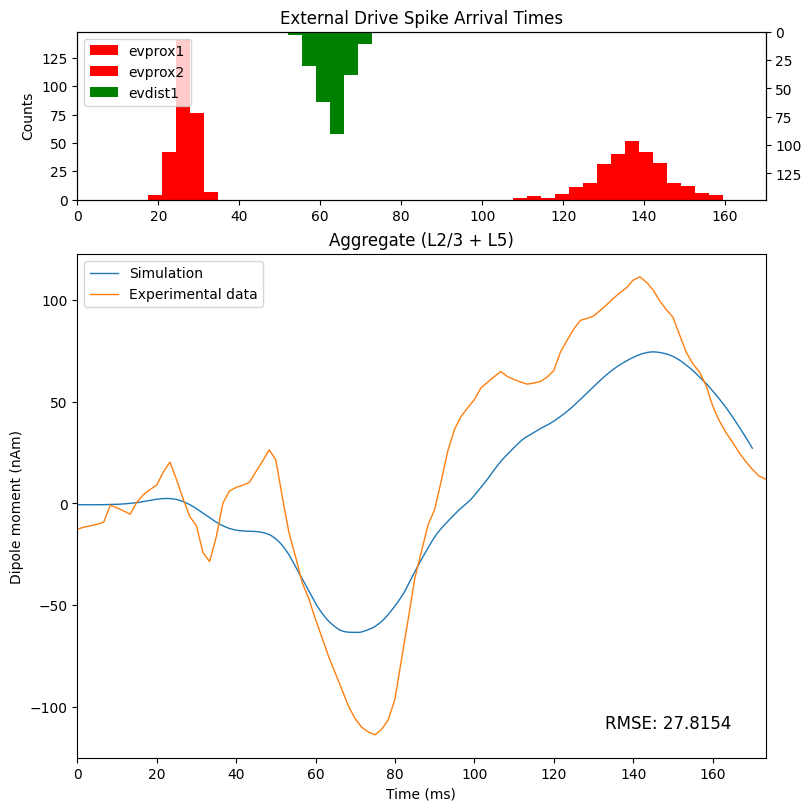

In [44]:
# fetch the new data from the `hnn-data` repository
data_url = "https://raw.githubusercontent.com/jonescompneurolab/hnn-data/main/MEG_detection_data/S1_SupraT.txt"
urlretrieve(
    data_url,
    "S1_SupraT.txt",
);  # noqa

# load the data as a `Dipole` object
suprathreshold_dpl = read_dipole(
    "S1_SupraT.txt",
)

# plot the data using our custom function
fig = plot_initial_gui_figure(
    net_default_gui,
    processed_dipole,
    suprathreshold_dpl,
)

Now that we see some notable differences in the signals, we can begin to develop hypotheses about what may have changed in the underlying network between the threshold and suprathreshold conditions. We can then select model parameters that represent those changes, and test out hypotheses via simulation. 

Let's say that after examining the differences between the default simulation and the suprathreshold data, we have two primary hypotheses:

  1. The external inputs to the local network are stronger than in the threshold condition. This could explain the differences in magnitude between several features of the waveform.

  2. The external inputs arrive earlier than they do in the threshold condition. This could explain differences in timing for several features of the waveform

As a first step, let's consider which evoked drive parameters we have access to in the model. 

One thing we have yet to discuss is how to add a drive to the network using the `add_evoked_drive` method of the network object. 

We can see all available drive parameters by inspecting the properties of the `add_evoked_drive` method, like so:

In [45]:
import inspect  # noqa

print(inspect.signature(net_default_gui.add_evoked_drive))

(name, *, mu, sigma, numspikes, location, n_drive_cells='n_cells', cell_specific=True, weights_ampa=None, weights_nmda=None, space_constant=3.0, synaptic_delays=0.1, probability=1.0, event_seed=2, conn_seed=3)


There are quite a few parameters we can adjust, and we've already discussed several of them in previous sections. 

Let's briefly walk through some of the key parameters for understanding how the evoked drives are defined, focusing on the ones that determine the timing, location, connectivity, and strength of the drives.

The timing of a drive is controlled by the `mu` and `sigma` parameters. `mu`, as we've established, is the *mean arrival time* of the drive. `sigma` is the *standard deviation*, and it determines the variability in arrival times.

The `location` parameter determines *where* the drives connect to the network, and it can be set either "proximal" or "distal" to target those locations in the local network.

The `weights_ampa` and `weights_nmda` parameters specify the strength of the excitatory synaptic connections from the drive to the target cells.

The `n_drive_cells` and `cell_specific` parameters determine *how* the drive cells connect to the network.

In the default network, `cell_specific` is set to "True" and `n_drive_cells` is set to "n_cells", which equals the total number of cells in the network. In the default case, a drive cell gets assigned to each available cell in the network with 1-to-1 connectivity. When `cell_specific` is "False", drive cells are assigned with all-to-all connectivity.

Finally, the `numspikes` parameter specifies the number of spikes generated by *each* drive cell. For the default evoked drives, this is set to 1. However, we vary the arrival times of the spikes at the network (through `sigma`) to represent a burst of input from the thalamus that arrives over a distribution of times. 

We can see most of these key parameters by simply viewing a drive object, and we can see a broader set of parameters by printing the keys for the drive object. Let's 

In [46]:
evprox1 = net_default_gui.external_drives["evprox1"]
print(
    "# " + "-"*40,
    "# Drive Object",
    "# " + "-"*40,
    evprox1,
    sep="\n"
)

print(
    "\n# " + "-"*40,
    "# Drive Object Keys",
    "# " + "-"*40,
    list(evprox1.keys()),
    sep="\n"
)

# ----------------------------------------
# Drive Object
# ----------------------------------------
<External drive 'evprox1'
drive class: evoked
target location: proximal
target cell types: ['L2_basket', 'L2_pyramidal', 'L5_basket', 'L5_pyramidal']
number of drive cells: 270
cell-specific: True
dynamic parameters:
	mu: 26.61
	sigma: 2.47
	numspikes: 1
event times instantiated for 1 trial>

# ----------------------------------------
# Drive Object Keys
# ----------------------------------------
['type', 'location', 'n_drive_cells', 'event_seed', 'conn_seed', 'dynamics', 'events', 'weights_ampa', 'weights_nmda', 'synaptic_delays', 'probability', 'name', 'target_types', 'cell_specific']


Rather than modify the default network directly, let's create a new network object. This lets us keep the default network available for comparison. 

Since we'll be adjusting model parameters, we'll call this instantiation of the model `net_01` to differentiate it from the default network.

In [47]:
# instantiate the default network
net_01 = jones_2009_model()

We'll start by testing the first hypothesis that the external inputs are stronger.

One way we can represent stronger inputs in the model is by increasing the AMPA weights of the drives. We could similarly increase the NMDA weights.'

However, for simplicity of the example, let's say we hypothesize that the differences in our suprathreshold data are specifically related to a change in AMPA-mediated excitation on the ***pyramidal neurons*** only.

Let's first print the AMPA weights for each drive:


In [48]:
for key, drive in net_default_gui.external_drives.items():
    print(f"{key}: {drive["weights_ampa"]}\n")

evdist1: {'L5_pyramidal': 0.1423, 'L2_pyramidal': 7e-06, 'L2_basket': 0.006562}

evprox1: {'L5_pyramidal': 0.00865, 'L2_pyramidal': 0.01525, 'L5_basket': 0.19934, 'L2_basket': 0.08831}

evprox2: {'L5_pyramidal': 0.684013, 'L2_pyramidal': 1.43884, 'L5_basket': 0.008958, 'L2_basket': 3e-06}



Next, we'll manually add new drives to `net_01` using the `add_evoked_drive` method. 

Note that we'll copy most parameters directly from their conterparts in the default network's `external_drives`, only changing some of the AMPA weights. Let's roughly increase the weight of each connection onto a pyramidal neuron by 5 fold. 

In [49]:
# create pointers to the default drives
# ----------------------------------------
evprox1 = net_default_gui.external_drives["evprox1"]
evdist1 = net_default_gui.external_drives["evdist1"]
evprox2 = net_default_gui.external_drives["evprox2"]

# add initial feedforward drive "evprox1"
# ---------------------------------------
# we'll first copy the ampa weights, then adjust them
# NOTE: to simplify the math, we round the orignial weights
# to one significant figure ***before*** multiplying by 5
evprox1_weights = evprox1["weights_ampa"].copy()
evprox1_weights["L2_pyramidal"] = 0.100  # ~ 0.020 * 5 = 0.100
evprox1_weights["L5_pyramidal"] = 0.045  # ~ 0.009 * 5 = 0.045

# we'll then add the drive with updated weights
net_01.add_evoked_drive(
    name="evprox1",
    mu=evprox1["dynamics"]["mu"],
    sigma=evprox1["dynamics"]["sigma"],
    numspikes=1,
    location="proximal",
    n_drive_cells="n_cells",
    cell_specific=True,
    weights_ampa=evprox1_weights,
    weights_nmda=evprox1["weights_nmda"],
    synaptic_delays=evprox1["synaptic_delays"],
    event_seed=evprox1["event_seed"],
)

# add feedback drive "evdist1"
# ---------------------------------------
# in this case, the L2_pyramidal weight is so small as to
# be negligible (7e-06). we'll arbitrarily set it to match
# our new value for the L5_pyramidal weight
evdist1_weights = evdist1["weights_ampa"].copy()

evdist1_weights["L5_pyramidal"] = 0.5  # ~ 0.1 * 5 = 0.5
evdist1_weights["L2_pyramidal"] = 0.5  # set to match L5

# we'll then add the drive
net_01.add_evoked_drive(
    name="evdist1",
    mu=evdist1["dynamics"]["mu"],
    sigma=evdist1["dynamics"]["sigma"],
    numspikes=1,
    location="distal",
    n_drive_cells="n_cells",
    cell_specific=True,
    weights_ampa=evdist1_weights,
    weights_nmda=evdist1["weights_nmda"],
    synaptic_delays=evdist1["synaptic_delays"],
    event_seed=evdist1["event_seed"],
)

# add second feedforward drive "evprox2"
# ---------------------------------------
# NOTE: we round L2_pyramidal to one decimal place below
evprox2_weights = evprox2["weights_ampa"].copy()

evprox2_weights["L2_pyramidal"] = 7.0  # ~ 1.4 * 5 = 7.0
evprox2_weights["L5_pyramidal"] = 3.5  # ~ 0.7 * 5 = 3.5

# we'll then add the drive
net_01.add_evoked_drive(
    name="evprox2",
    mu=evprox2["dynamics"]["mu"],
    sigma=evprox2["dynamics"]["sigma"],
    numspikes=1,
    location="proximal",
    n_drive_cells="n_cells",
    cell_specific=True,
    weights_ampa=evprox2_weights,
    weights_nmda=evprox2["weights_nmda"],
    synaptic_delays=evprox2["synaptic_delays"],
    event_seed=evprox2["event_seed"],
)

# and we'll print the names of all drives to confirm
# they were added correctly
print(
    "Drives added:",
    list(net_01.external_drives.keys())
)

Drives added: ['evprox1', 'evdist1', 'evprox2']


Now let's run the simulation, preprocess the dipole, and plot the results against the data.

In [50]:
with chosen_backend(ncores):
    dipoles_list = simulate_dipole(
        net=net_01,
        tstop=170.0,
        n_trials=1,
        dt=0.025,
    )

net_01_dpl_01 = dipoles_list[0].copy()
net_01_dpl_01.smooth(30).scale(3000)
# mod_shrink_output

MPI will run 1 trial(s) sequentially by distributing network neurons over 4 processes.
/opt/homebrew/Caskroom/miniconda/base/envs/dev/bin/nrniv:10: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  from pkg_resources import working_set
/opt/homebrew/Caskroom/miniconda/base/envs/dev/bin/nrniv:10: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  from pkg_resources import working_set
/opt/homebrew/Caskroom/miniconda/base/envs/dev/bin/nrniv:10: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  from pkg_resources import working_set
/opt/homebrew/Caskroom/miniconda/base/envs/dev/bin/nrniv:10: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  from pkg_resources import working_set
numprocs=4
Loading custom mechani

We can add our previous simulation to the plot as well to compare the simulations.

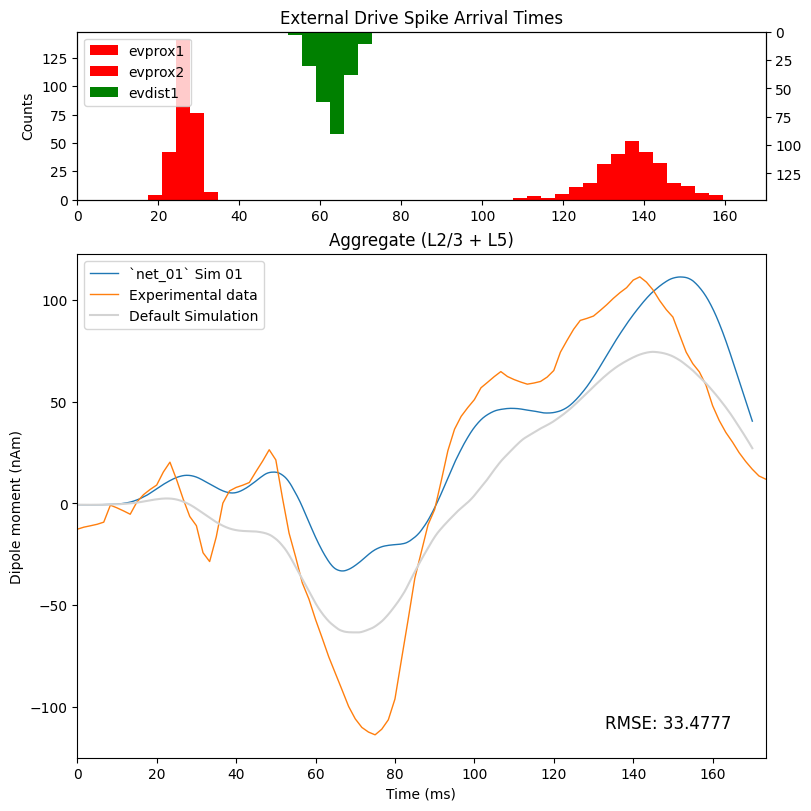

In [51]:
# plot the data using our custom function
fig = plot_initial_gui_figure(
    net_01,
    net_01_dpl_01,
    suprathreshold_dpl,
    "`net_01` Sim 01"
)

fig.axes[1].plot(
    processed_dipole.times,
    processed_dipole.data["agg"],
    label="Default Simulation",
    color="#D3D3D3"
)

fig.axes[1].legend();

Even though the RMSE is worse for the new simulation, some features of the new simulation look more representative of the suprathreshold data. For example, the wavwform shapes around the first and second proximal drives look closer to the data, but the timing of the peaks is shifted. On the other hand, the simulation looks worse overall around the time of the distal drive. 

Next, let's test the hypothesis that the inputs arrive earlier to the network. To do this, we can shift the mean arrival time of each drive to be slightly earlier.

Rather than re-adding the drives manually, as we did above, we can simply edit the parameters in the current network, and then rerun the simulation.

The mean arrival time ("mu") for each drive is as follows:


In [52]:
for name, drive in net_01.external_drives.items():
    print(f"{name}: {drive["dynamics"]["mu"]}")

evprox1: 26.61
evdist1: 63.53
evprox2: 137.12


Lets shift each drive to be earlier in time. We'll make a more pronounced change to the proximal drives, as the time-shift in those drives appears more pronounced.

In [53]:
# first we'll create a dictionary of updated
# mean arrival times for the drives
update_arrival_times = {
    "evprox1": 18,
    "evdist1": 63,
    "evprox2": 130,
}

# then, we'll loop through the drives and update the "mu"
# parameter for each drive, using the name as the key
for name, drive in net_01.external_drives.items():
    print(f"\nUpdating {name}...")
    print(f"    starting value: {drive["dynamics"]["mu"]}")
    drive["dynamics"]["mu"] = update_arrival_times[name]
    print(f"    `mu` now set to {drive["dynamics"]["mu"]}")


Updating evprox1...
    starting value: 26.61
    `mu` now set to 18

Updating evdist1...
    starting value: 63.53
    `mu` now set to 63

Updating evprox2...
    starting value: 137.12
    `mu` now set to 130


And we'll re-simute the network and generate our dipole comparison plot once again

In [54]:
with chosen_backend(ncores):
    dipoles_list = simulate_dipole(
        net=net_01,
        tstop=170.0,
        n_trials=1,
        dt=0.025,
    )

net_01_dpl_02 = dipoles_list[0].copy()
net_01_dpl_02.smooth(30).scale(3000)
# mod_shrink_output


MPI will run 1 trial(s) sequentially by distributing network neurons over 4 processes.
/opt/homebrew/Caskroom/miniconda/base/envs/dev/bin/nrniv:10: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  from pkg_resources import working_set
/opt/homebrew/Caskroom/miniconda/base/envs/dev/bin/nrniv:10: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  from pkg_resources import working_set
/opt/homebrew/Caskroom/miniconda/base/envs/dev/bin/nrniv:10: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  from pkg_resources import working_set
/opt/homebrew/Caskroom/miniconda/base/envs/dev/bin/nrniv:10: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  from pkg_resources import working_set
numprocs=4
Loading custom mechani

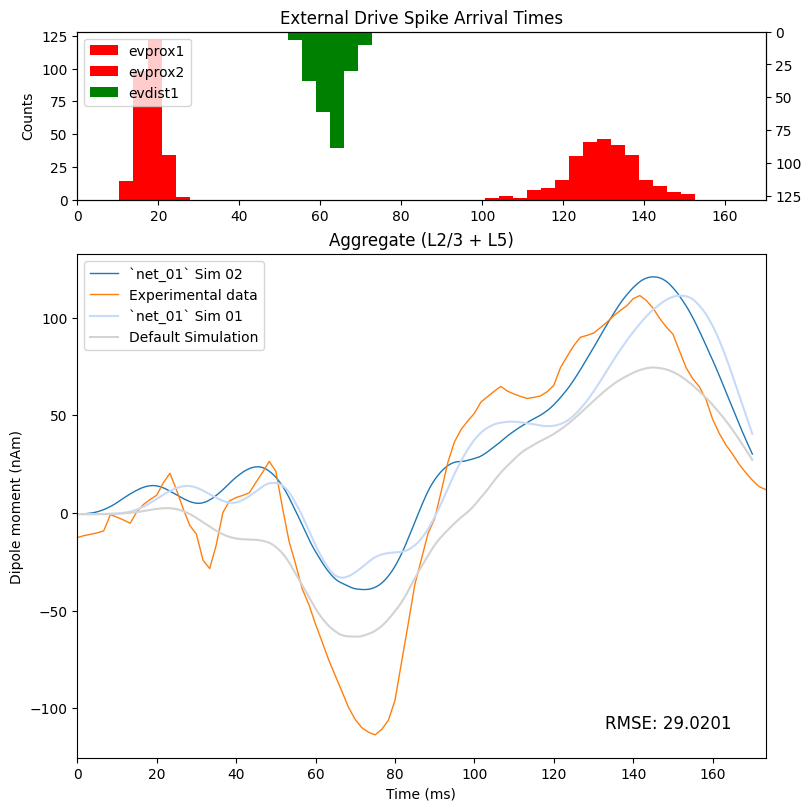

In [55]:
# plot the data using our custom function
fig = plot_initial_gui_figure(
    net_01,
    net_01_dpl_02,
    suprathreshold_dpl,
    "`net_01` Sim 02",
)

fig.axes[1].plot(
    net_01_dpl_01.times,
    net_01_dpl_01.data["agg"],
    label="`net_01` Sim 01",
    color="#C8DAF9"
)

fig.axes[1].plot(
    processed_dipole.times,
    processed_dipole.data["agg"],
    label="Default Simulation",
    color="#D3D3D3",
)

fig.axes[1].legend();

The timing of the peaks does look better than the previous simulation, though we could likely improve the fit further by continuing to hand-tune the values. For example, we may have overshot out target peaks by shifting the first proximal drive to bee too early in time.

However, for now, let's move on to exploring other parameters. Specifically, let's see if we can improve the fit around the distal drive. 

Consistent with our hypothesis on the timing of the drives being shifted, we can also very the `sigma` parameter to make the distal drive more synchronous. Let's try reducing the value of sigma to 1.5

In [56]:
evdist1_net_01 = net_01.external_drives["evdist1"]
print(f"Updating `sigma` for {name}...")
print(
    "    starting value: "
    f"{evdist1_net_01["dynamics"]["sigma"]}"
)
evdist1_net_01["dynamics"]["sigma"] = 1.5
print(
    "    `sigma` now set to "
    f"{evdist1_net_01["dynamics"]["sigma"]}"
)

Updating `sigma` for evprox2...
    starting value: 3.85
    `sigma` now set to 1.5


In [57]:
with chosen_backend(ncores):
    dipoles_list = simulate_dipole(
        net=net_01,
        tstop=170.0,
        n_trials=1,
        dt=0.025,
    )

net_01_dpl_03 = dipoles_list[0].copy()
net_01_dpl_03.smooth(30).scale(3000)
# mod_shrink_output

MPI will run 1 trial(s) sequentially by distributing network neurons over 4 processes.
/opt/homebrew/Caskroom/miniconda/base/envs/dev/bin/nrniv:10: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  from pkg_resources import working_set
/opt/homebrew/Caskroom/miniconda/base/envs/dev/bin/nrniv:10: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  from pkg_resources import working_set
/opt/homebrew/Caskroom/miniconda/base/envs/dev/bin/nrniv:10: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  from pkg_resources import working_set
/opt/homebrew/Caskroom/miniconda/base/envs/dev/bin/nrniv:10: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  from pkg_resources import working_set
numprocs=4
Loading custom mechani

We'll only plot the two most recent simulations for readability

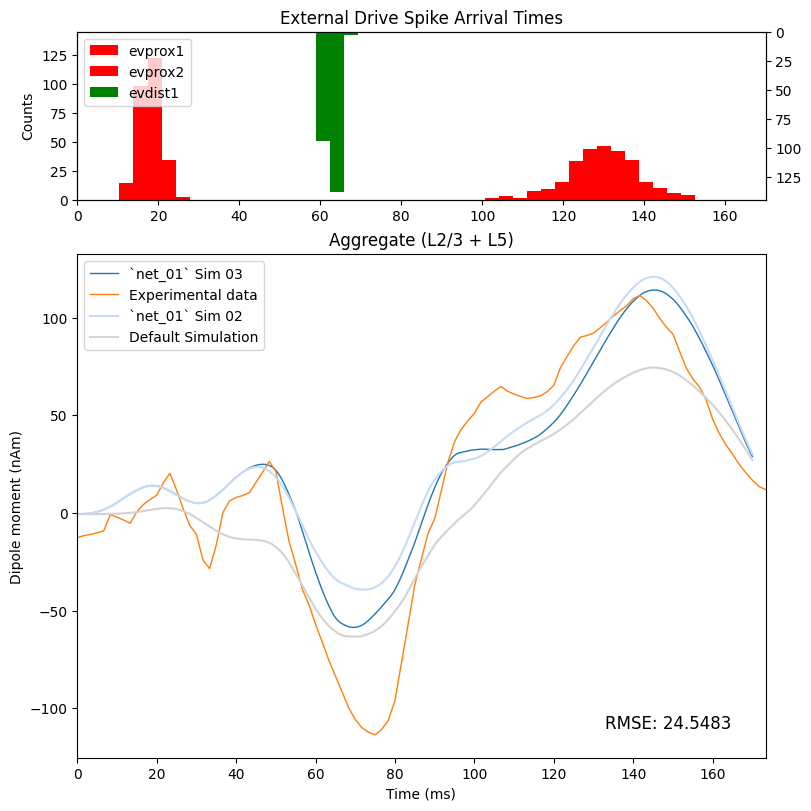

In [58]:

# plot the data using our custom function
fig = plot_initial_gui_figure(
    net_01,
    net_01_dpl_03,
    suprathreshold_dpl,
    "`net_01` Sim 03",
)

fig.axes[1].plot(
    net_01_dpl_02.times,
    net_01_dpl_02.data["agg"],
    label="`net_01` Sim 02",
    color="#C8DAF9"
)

fig.axes[1].plot(
    processed_dipole.times,
    processed_dipole.data["agg"],
    label="Default Simulation",
    color="#D3D3D3",
)

fig.axes[1].legend();

Once again, the signal appears to have improved. In this case, it could be that the more-synchronous distal depolarization from the distal drive is driving the strong "inward" current observable in the aggregate dipole. Though we would need to examine the circuit-level details to explore that idea.

Changing `sigma` also appears to have slightly shifted the timing of the peak around 70ms. This is not entirely unexpected, as reducing the standard deviation means the peak will be narrower arround the mean.

Let's make a small adjustment to the mean arrival time of the distal drive to account for this shift. 

In [59]:
evdist1_net_01 = net_01.external_drives["evdist1"]
print(f"Updating `mu` for {name}...")
print(
    "    starting value: "
    f"{evdist1_net_01["dynamics"]["mu"]}"
)
evdist1_net_01["dynamics"]["mu"] = 65
print(
    "    `mu` now set to "
    f"{evdist1_net_01["dynamics"]["mu"]}"
)

Updating `mu` for evprox2...
    starting value: 63
    `mu` now set to 65


In [60]:
with chosen_backend(ncores):
    dipoles_list = simulate_dipole(
        net=net_01,
        tstop=170.0,
        n_trials=1,
        dt=0.025,
    )

net_01_dpl_04 = dipoles_list[0].copy()
net_01_dpl_04.smooth(30).scale(3000)
# mod_shrink_output

MPI will run 1 trial(s) sequentially by distributing network neurons over 4 processes.
/opt/homebrew/Caskroom/miniconda/base/envs/dev/bin/nrniv:10: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  from pkg_resources import working_set
/opt/homebrew/Caskroom/miniconda/base/envs/dev/bin/nrniv:10: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  from pkg_resources import working_set
/opt/homebrew/Caskroom/miniconda/base/envs/dev/bin/nrniv:10: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  from pkg_resources import working_set
/opt/homebrew/Caskroom/miniconda/base/envs/dev/bin/nrniv:10: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  from pkg_resources import working_set
numprocs=4
Loading custom mechani

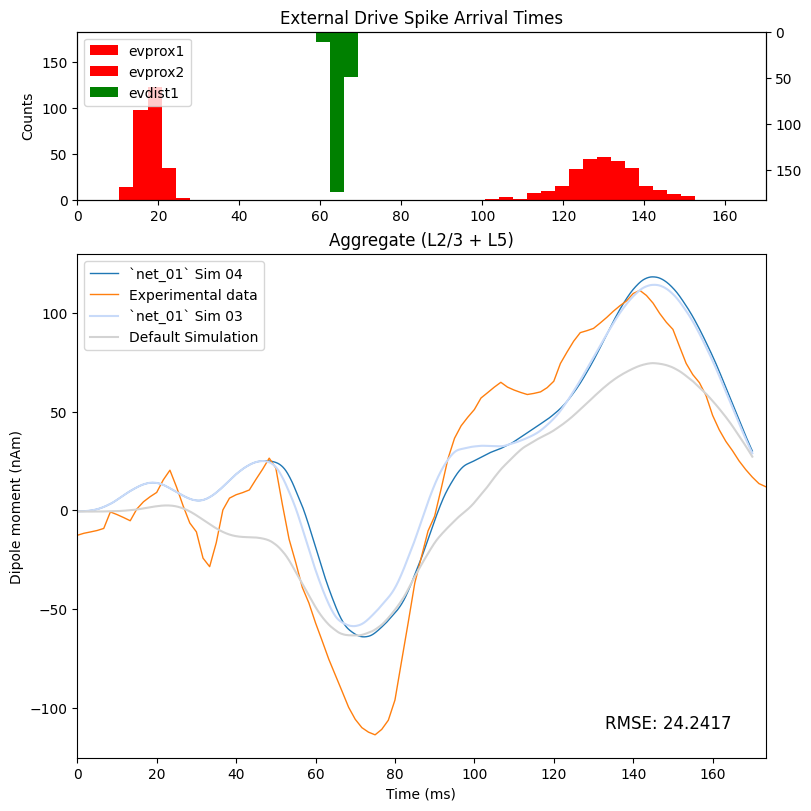

In [61]:
# plot the data using our custom function
fig = plot_initial_gui_figure(
    net_01,
    net_01_dpl_04,
    suprathreshold_dpl,
    "`net_01` Sim 04",
)

fig.axes[1].plot(
    net_01_dpl_03.times,
    net_01_dpl_03.data["agg"],
    label="`net_01` Sim 03",
    color="#C8DAF9"
)

fig.axes[1].plot(
    processed_dipole.times,
    processed_dipole.data["agg"],
    label="Default Simulation",
    color="#D3D3D3",
)

fig.axes[1].legend();

The timing is now much more in line with the experimental data, and the fit around the distal drive is fairly close to our starting point.

The simulation in its current state is by no means a perfect representation of the data, and there are still many areas we could improve with more hand tuning. But you can see that the RMSE has improved from our starting point, and we have a waveform that at least looks *more* representative of the data.

Keep in mind that, in practice, we would not rely on the aggregate dipole *alone* for tuning parameters. We would also want to look at the layer-specific dipoles, spike raster plots, and potentially other figures as we go through this iterative parameter adjustment process, as we illustrated in the previous **Multiscale Interpretation** sections. 

The point of this exercise was not to arrive at a perfectly hand-tuned simulation, but rather, to give you insight into how we think about tuning parameters in HNN. And the end goal of this hand-tuning process is not to minimize the RMSE between the simulation and the data. ***The goal is to develop and test hypotheses about the circuit mechanisms that generated your data.***

The underlying circuit information that comes out of the model can then give you targets for validation in follow-up experiments (e.g., with invasive animal recording, or other imaging modalities)

# Textbook Section 4.9

## Hand Tuning Drive Parameters

In the previous section, we focused on adjusting evoked drive parameters to develop hypotheses about differences between our model and experimental data. 

In this section, we'll explore hand tuning parameters of the local network.

As we discussed in the previous section, we generally recommend starting by hand-tuning the evoked drives of one of our default networks when working with experimental ERP data. Changing the local network should generally be motivated by a specific scientific hypothesis about differences in the population being studied.


Let's first look at the properties of the individual cell types in the network.

These are stored in the `cell_types` attribute of the network object. For example, we can inspect the available cell types by printing the keys in the `cell_types` data dictionary.

In [62]:
print(list(net_default_gui.cell_types.keys()))

['L2_basket', 'L2_pyramidal', 'L5_basket', 'L5_pyramidal']


Each cell type is essentially a dictionary that contains a `Cell` object as well as metadata describing the cell type. 

Below, we examine a subset of the `Cell` object's parameters.

  - `sect_loc` will show which sections make up the "proximal" and "distal" connection points

  - `sections` provides the detailed geometry for each section of the celltype 

  - `synapses` defines reversal potential, rise time, and decay time for each synapse type


In [63]:
l5_pyr_celltype = net_default_gui.cell_types["L5_pyramidal"]
l5_pyr_object = l5_pyr_celltype["cell_object"]

print(
    l5_pyr_object.sect_loc,
    l5_pyr_object.sections,
    l5_pyr_object.synapses,
    sep="\n\n"
)

{'proximal': ['apical_oblique', 'basal_2', 'basal_3'], 'distal': ['apical_tuft']}

{'apical_trunk': L=102.0, diam=10.2, cm=0.85, Ra=200.0, v0=-72, 'apical_1': L=680.0, diam=7.48, cm=0.85, Ra=200.0, v0=-71.32, 'apical_2': L=680.0, diam=4.93, cm=0.85, Ra=200.0, v0=-69.08, 'apical_tuft': L=425.0, diam=3.4, cm=0.85, Ra=200.0, v0=-67.3, 'apical_oblique': L=255.0, diam=5.1, cm=0.85, Ra=200.0, v0=-72, 'basal_1': L=85.0, diam=6.8, cm=0.85, Ra=200.0, v0=-72, 'basal_2': L=255.0, diam=8.5, cm=0.85, Ra=200.0, v0=-72, 'basal_3': L=255.0, diam=8.5, cm=0.85, Ra=200.0, v0=-72, 'soma': L=39.0, diam=28.9, cm=0.85, Ra=200.0, v0=-72.0}

{'ampa': {'e': 0.0, 'tau1': 0.5, 'tau2': 5.0}, 'nmda': {'e': 0.0, 'tau1': 1.0, 'tau2': 20.0}, 'gabaa': {'e': -80.0, 'tau1': 0.5, 'tau2': 5.0}, 'gabab': {'e': -80.0, 'tau1': 1.0, 'tau2': 20.0}}


If we look at any *particular* section, we can see that there are additional attributes (some public, some private) that aren't explicitly displayed when we print the `Section` object above.  We can inspect them using the object's `__dict__`

In [64]:
l5_pyr_soma = l5_pyr_object.sections["soma"]

print(
    'Printout for sections["soma"]:',
    f"    {l5_pyr_soma}",
    '\nAttributes for sections["soma"]:',
    f"    {list(l5_pyr_soma.__dict__.keys())}",
    sep="\n",
)

Printout for sections["soma"]:
    L=39.0, diam=28.9, cm=0.85, Ra=200.0, v0=-72.0

Attributes for sections["soma"]:
    ['_L', '_diam', '_Ra', '_cm', '_v0', '_end_pts', 'mechs', 'syns', 'nseg']


While the keys above correspond to attributes of the `Section` object, they are not displayed when printing the value for any particular section, as they are not part of the `Section` object's public-facing representation. 

This means we can only access them by using attribute syntax, as opposed to dictionary syntax. For example, we can inspect the mechanisms for the `soma` with:

In [65]:
l5_pyr_object.sections["soma"].mechs

{'hh2': {'gkbar_hh2': 0.01,
  'gnabar_hh2': 0.16,
  'el_hh2': -65.0,
  'gl_hh2': 4.26e-05},
 'ca': {'gbar_ca': 60.0},
 'cad': {'taur_cad': 20.0},
 'kca': {'gbar_kca': 0.0002},
 'km': {'gbar_km': 200.0},
 'cat': {'gbar_cat': 0.0002},
 'ar': {'gbar_ar': 1e-06}}

We could also use the `to_dict()` method of the `Cell` object to store all of the cell parameters as a dictionary. However, we *cannot* use the output to *update* parameters, only to inspect them.

Since the dictionary is quite large, we do not print the output of `to_dict()` below, but if you would like to see it, you can un-comment the cell and rerun it.

In [66]:
# l5_pyr_object.to_dict()

While it's important to understand how to access and update the cell parameters, the rest of this section will focus on making changes to the weights (strengths) of the connections in the local network. We'll once again use the default network as our starting point for hand-tuning parameters. 

For this example below, imagine that the default simulation represents a neurotypical population performing the threshold-level tactile-detection task, and the experimental data represents an autism spectrum disorder (ASD) population performing the *same* tactile detection task. 

In this hypothetical setup, the task is the same, but the *populations* differ. (Note that we will still use the suprathreshold experimental data, but we are imagining that it represents our ASD population rather than a different experimental condition).

We'll start, once again, from the figure below.

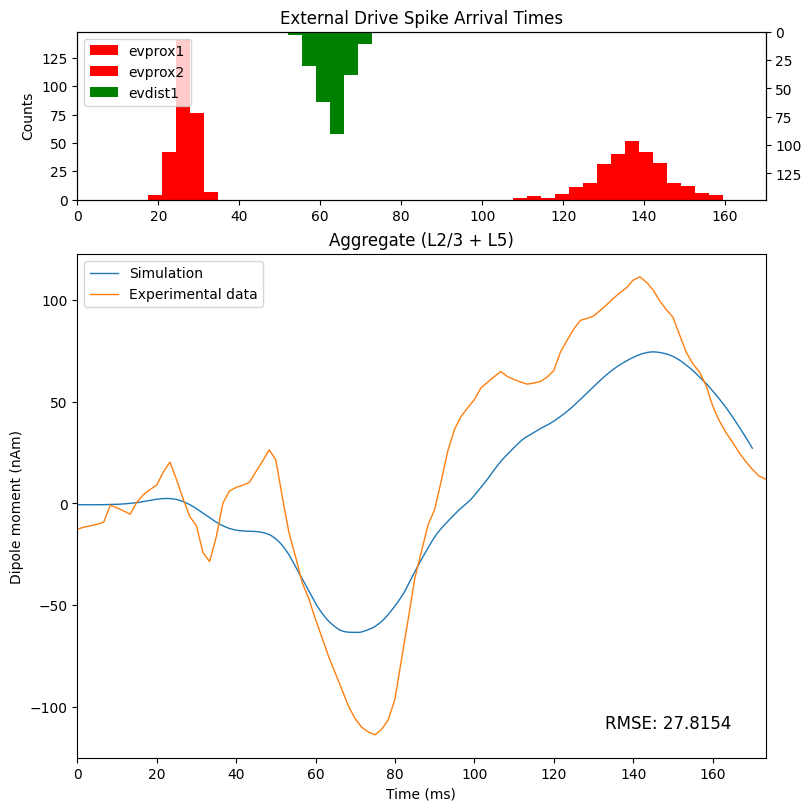

In [67]:
fig = plot_initial_gui_figure(
    net_default_gui,
    processed_dipole,
    suprathreshold_dpl,
)

Note that, in this setup, we are starting with an existing model for the neurotypical population. We will use this model as a starting point to develop a new model for our ASD population.

Let's say we know the specific ASD population we’re studying has sensory hypersensitivity, which we think is responsible for the observed differences in the ERP signals. Specifically, we think differences in E-I balance in the local cortical column are responsible. 

Let's consider some hypotheses for the observed differences between the populations.

  1. One possibility is that there's increased amplification of our sensory inputs in this local cortical circuit. In this case, we would expect stronger excitatory connections between cells in the network.

  2. A second possibility is that there is reduced inhibitory regulation of the pyramidal neurons. In this case, we would expect weaker inhibitory connections onto the pyramidal neurons.

We can test each hypothesis in turn by changing the weights of the corresponding connections in the model and examining how those changes affect the simulated ERP.

The connections and their associated parameters are found in the `connectivity` attribute of the `Network` object. Since the connectivity object returns a list of connections, we can print the first entry to examine its properties

In [68]:
net_default_gui.connectivity[0]

L2_pyramidal -> L2_pyramidal
cell counts: 100 srcs, 100 targets
connection probability: 1.0 
loc: 'proximal'; receptor: 'nmda'
weight: 0.0005; delay: 1.0; lamtha: 3.0threshold: 0.0gain: 1.0
 

This particular entry in the connectivity list shows the parameters that specify the connections between L2 pyramidal neurons.

The `cell counts`, `connection probability`, and `loc` describe how many cells are connected and the connection location, while `lamtha` determines how the connection probability varies with the distance between cells. `delay` specifies the latency between a presynaptic spike and postsynaptic response, while `threshold` specifies the voltage threshold for detecting a presynaptic spike. 

To test our first hypothesis, let's adjust the weight of all excitatory connections in the local network. This includes the recurrent connections between pyramidal neurons, and the connections from pyramidal neurons onto interneurons.

First, let's create a new `Network` object by "deep copying" the default network. We'll call this network `net_02`

In [69]:
from copy import deepcopy  # noqa

net_02 = read_network_configuration("gui_default.json")

Now, rather than individually adjusting the weight for each connection type, we can use the `set_global_synaptic_gains()` method of the `Network` object to adjust entire *classes* of connections at once.

This method accepts arguments that correspond to one of four classes of connections

  - excitatory to excitatory (`e_e`)

  - excitatory to inhibitory (`e_i`)

  - inhibitory to inhibitory (`i_i`)

  - inhibitory to excitatory (`i_e`)

To test our first hypothesis, let's try doubling the `e_e` and `e_i` gains to represent the increased amplification of sensory inputs. We can then print the global gain values using the `get_global_synaptic_gains()` method to ensure that the gains were correctly updated. 

In [70]:
net_02.set_global_synaptic_gains(
    e_e=2,
    e_i=2,
)

print(net_02.get_global_synaptic_gains())

{'e_e': 2, 'e_i': 2, 'i_e': 1.0, 'i_i': 1.0}


We can then simulate the network with the updated gains 

In [71]:
with chosen_backend(ncores):
    net_02_dpl_01 = simulate_dipole(
        net=net_02,
        tstop=170.0,
        n_trials=1,
        dt=0.025,
    )

processed_dpl_02_01 = net_02_dpl_01[0].copy()
processed_dpl_02_01.smooth(30).scale(3000)
# mod_shrink_output

MPI will run 1 trial(s) sequentially by distributing network neurons over 4 processes.
/opt/homebrew/Caskroom/miniconda/base/envs/dev/bin/nrniv:10: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  from pkg_resources import working_set
/opt/homebrew/Caskroom/miniconda/base/envs/dev/bin/nrniv:10: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  from pkg_resources import working_set
/opt/homebrew/Caskroom/miniconda/base/envs/dev/bin/nrniv:10: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  from pkg_resources import working_set
/opt/homebrew/Caskroom/miniconda/base/envs/dev/bin/nrniv:10: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  from pkg_resources import working_set
numprocs=4
Loading custom mechani

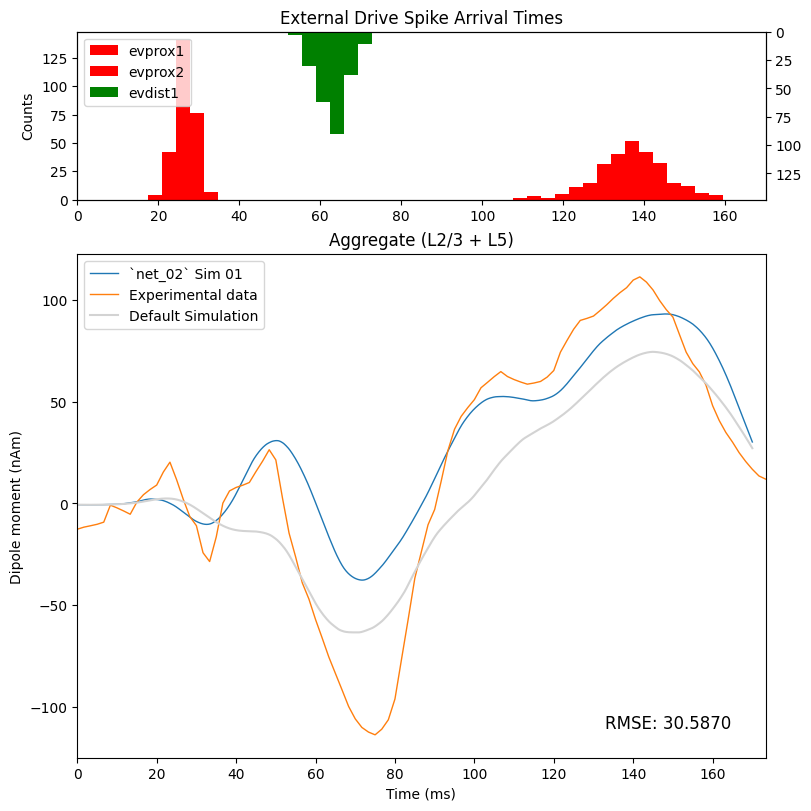

In [72]:
# plot the data using our custom function
fig = plot_initial_gui_figure(
    net_02,
    processed_dpl_02_01,
    suprathreshold_dpl,
    "`net_02` Sim 01",
)

fig.axes[1].plot(
    processed_dipole.times,
    processed_dipole.data["agg"],
    label="Default Simulation",
    color="#D3D3D3",
)

fig.axes[1].legend();

Compared to our default simulation, the root mean squared error is actually worse. However, there are parts of the simulation that look more representative of the data.

Around the second proximal drive, the amplitude of the signal is higher and more closely matches the two-peak shape of the data. The fit around the first proximal drive also looks somewhat better, specifically near the peak around 50ms. 

In this hypothetical scenario, this could be a reasonable starting point for further exploration and hand tuning. From here, we could experiment with different gain values, or we could keep the updated global gains and further hand tune the evoked drives to see if we can improve the simulation further.

In the previous examples, we've re-simulated the same `Network` object after changing parameters, while separately saving the dipole object for each simulation.

Note, however, that re-simulating the *same* network object overwrites both the network parameters *and* any data associated with the network simulation, such as the spiking data in `CellResponse`

Before moving on, let's create a copy of the network in case we want to view the `CellResponse` data at a later time. This also enables us to continue hand-tuning the network from the point we left off, without needing to re-simulate it later. We'll call the copy `net_02_checkpoint_01`

In [73]:
net_02_checkpoint_01 = deepcopy(net_02)

Note that you can also save a copy of the updated network file to your local machine with the `write_network_configuration()` method, and you can then load it at a later time with the same `read_network_configuration()` method used above. 

In [74]:
from hnn_core import write_network_configuration

save_to_disk = False

if save_to_disk:
    write_network_configuration(
        net_02_checkpoint_01,
        "net_02_checkpoint_01.json",
    )

Rather than continuing to refine the first simulation at this time, let's test our second hypothesis that the differences in the signals are due to reduced inhibitory regulation of the pyramidal neurons.

To test this hypothesis, we'll reset the excitatory global gains to their default values and instead reduce the `i_e` global gain, which controls the strength of inhibitory connections onto excitatory cells.

Let's try reducing this gain by 50% and see how this change affects the simulated ERP. In this case, we predict that less inhibition of the pyramidal neurons will yield an overall stronger response. 

In [75]:
net_02.set_global_synaptic_gains(
    e_e=1,
    e_i=1,
    i_e=0.5,  # i.e., 50%
)

print(net_02.get_global_synaptic_gains())

{'e_e': 1, 'e_i': 1, 'i_e': 0.5, 'i_i': 1.0}


In [76]:
with chosen_backend(ncores):
    net_02_dpl_02 = simulate_dipole(
        net=net_02,
        tstop=170.0,
        n_trials=1,
        dt=0.025,
    )

processed_dpl_02_02 = net_02_dpl_02[0].copy()
processed_dpl_02_02.smooth(30).scale(3000)
# mod_shrink_output

MPI will run 1 trial(s) sequentially by distributing network neurons over 4 processes.
/opt/homebrew/Caskroom/miniconda/base/envs/dev/bin/nrniv:10: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  from pkg_resources import working_set
/opt/homebrew/Caskroom/miniconda/base/envs/dev/bin/nrniv:10: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  from pkg_resources import working_set
/opt/homebrew/Caskroom/miniconda/base/envs/dev/bin/nrniv:10: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  from pkg_resources import working_set
/opt/homebrew/Caskroom/miniconda/base/envs/dev/bin/nrniv:10: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  from pkg_resources import working_set
numprocs=4
Loading custom mechani

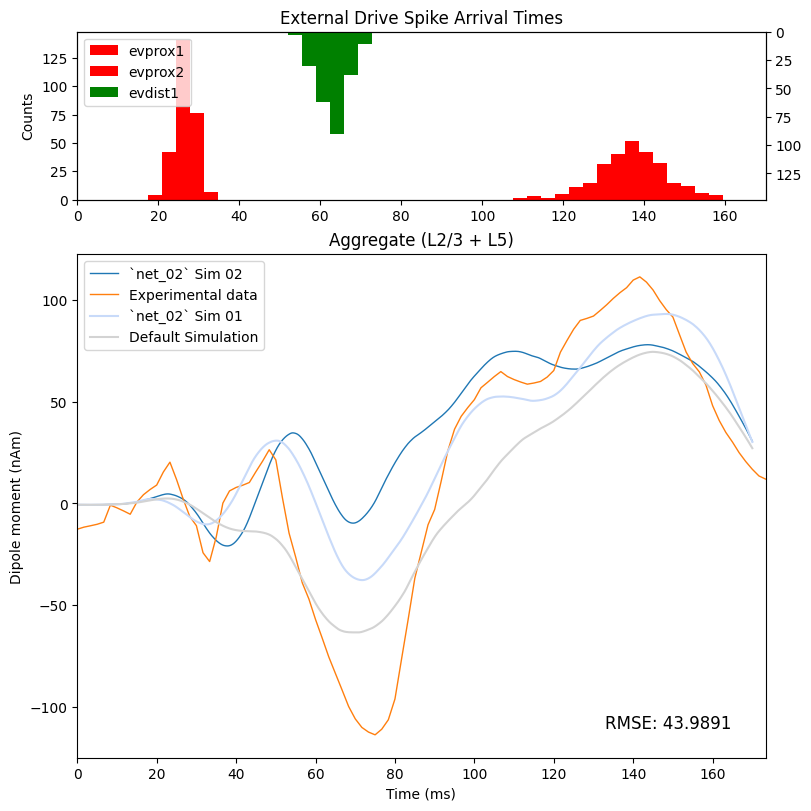

In [77]:
# plot the data using our custom function
fig = plot_initial_gui_figure(
    net_02,
    processed_dpl_02_02,
    suprathreshold_dpl,
    "`net_02` Sim 02",
)

fig.axes[1].plot(
    processed_dpl_02_01.times,
    processed_dpl_02_01.data["agg"],
    label="`net_02` Sim 01",
    color="#C8DAF9"
)

fig.axes[1].plot(
    processed_dipole.times,
    processed_dipole.data["agg"],
    label="Default Simulation",
    color="#D3D3D3",
)

fig.axes[1].legend();

In this case, the new simulation looks notably worse than the previous simulation. This suggests that perhaps our proposed mechanism (decreasing the strength of the `i_e` connections) isn't sufficient to account for the differences in these populations' dipole signals, at least not on its own.

But the point here isn't that our parameter changes have given us a definite answer either way. The point is that we start with observed differences between our simulation and the data, and we propose testable parameter changes based on our hypotheses about the underlying differences in the signal generators. The model allows us to test our predictions through simulations.

In this case, it looks like reducing inhibitory connections did not produce a better match between the simulation and the data. Between these two new simulations, our first simulation appears to be a more promising direction to explore. It suggests that, in the context of this exercise, increased excitatory recruitment in the local network could be a plausible explanation for *some* of the observed differences in the dipoles.

However, it's important to emphasize that the aggregate dipole alone does ***not*** give us the full picture of what's happening in the model. We can't tell from this figure why the fit improved, or whether the underlying activity is biologically plausible.

In the next section, we will examine the underlying circuit dynamics to better understand what changed in the model *between* the two simulations. We will also give an example of how to identify potential targets for validation in follow-up experiments

# Textbook Section 4.10

## From Hypotheses to Validation Targets

In the previous section, we set up a hypothetical example in which the default simulation represented a neurotypical population performing the threshold-level tactile-detection task, while the experimental data represented an ASD population with sensory hypersensitivity performing the *same* task. 

We then proposed two hypotheses for the observed differences in the dipole signals:
  1. Increased amplification of sensory inputs via stronger local excitatory connections
  2. Reduced inhibitory regulation of pyramidal neurons

After testing both hypotheses, we concluded that the simulation with stronger excitatory "E-E" and "E-I" connections yielded the more promising fit to the experimental data, suggesting that increased excitatory recruitment in the local network *could* contribute to *some* of the observed differences in the dipole signals.

However, it's important to emphasize that the aggregate dipole alone does ***not*** give us the full picture of what's happening in the model. We can't tell from our initial dipole plot why the fit improved, or whether the underlying activity is biologically plausible.

To develop more specific predictions about the mechanisms underlying the observed differences, we can examine the underlying cell and circuit activity in the model.

There are many ways to investigate the underlying activity, such as observing the layer-specific dipoles, spiking activity, or local field potentials. We encourage you to explore `Section 7: Using the API`, which contains advanced tutorials covering several API-specific features, such as recording extracellular potentials.

In the current section, we'll compare spike raster plots to explore how the simulation outputs can be used to identify targets for experimental validation. This is meant to be an illustrative example, not a comprehensive one, and is functionally similar to the more comprehensive analysis exercise we covered in `Section 4.7: Multiscale Interpretation`. 

Before diving into the interpretation exercise, let's briefly refresh on how simulation output data are represented in HNN.

As a reminder, the simulated dipole data are stored *separately* from the network and are returned by the `simulate_dipole()` function. Other simulation data, such as the celltype-specific spiking, are stored *with* the network in the `CellResponse` attribute. 

Let's examine the public attributes of `CellResponse`

In [78]:
# initialize empty list to store attributes
public_attributes = []

for attribute in dir(net_default_gui.cell_response):
    # ignore private attributes (those that start with "_")
    if not attribute.startswith("_"):
        public_attributes.append(attribute)

# print the public attribues
print(public_attributes)

['ca', 'cell_types', 'isec', 'mean_rates', 'plot_spikes_hist', 'plot_spikes_raster', 'spike_gids', 'spike_times', 'spike_times_by_type', 'spike_types', 'times', 'to_dict', 'update_types', 'vsec', 'write']


Note that the CellResponse object has various attributes related to spiking data. We've already made use of the methods `plot_spikes_hist` and `plot_spikes_raster`. Should you need to access the underlying data for your own analysis, the raw spike data are available under the `spike_times`, `spike_gids`, `spike_types`, and `spike_times_by_type` data attributes.

There are also additional output data stored with the `CellResponse` object. For example, the `isec` and `ca` data attributes contain the (optionally-recorded) synaptic currents and calcium concentration, respectively.

In previous sections, we defined custom functions that call `plot_spikes_hist()` and `plot_spikes_raster()` with pre-specified arguments. For the analysis below, we'll reuse these functions to create a new figure that shows:
  1. The input histogram (which is identical for the two simulations)
  2. The spike raster for the default simulation, and
  3. The spike raster for our *updated* simulation (testing the "local amplification" hypothesis)

Since we made a copy of `net_02` after changing parameters to test the increased amplification hypothesis, we already have the `CellResponse` data we need to create our new figure.

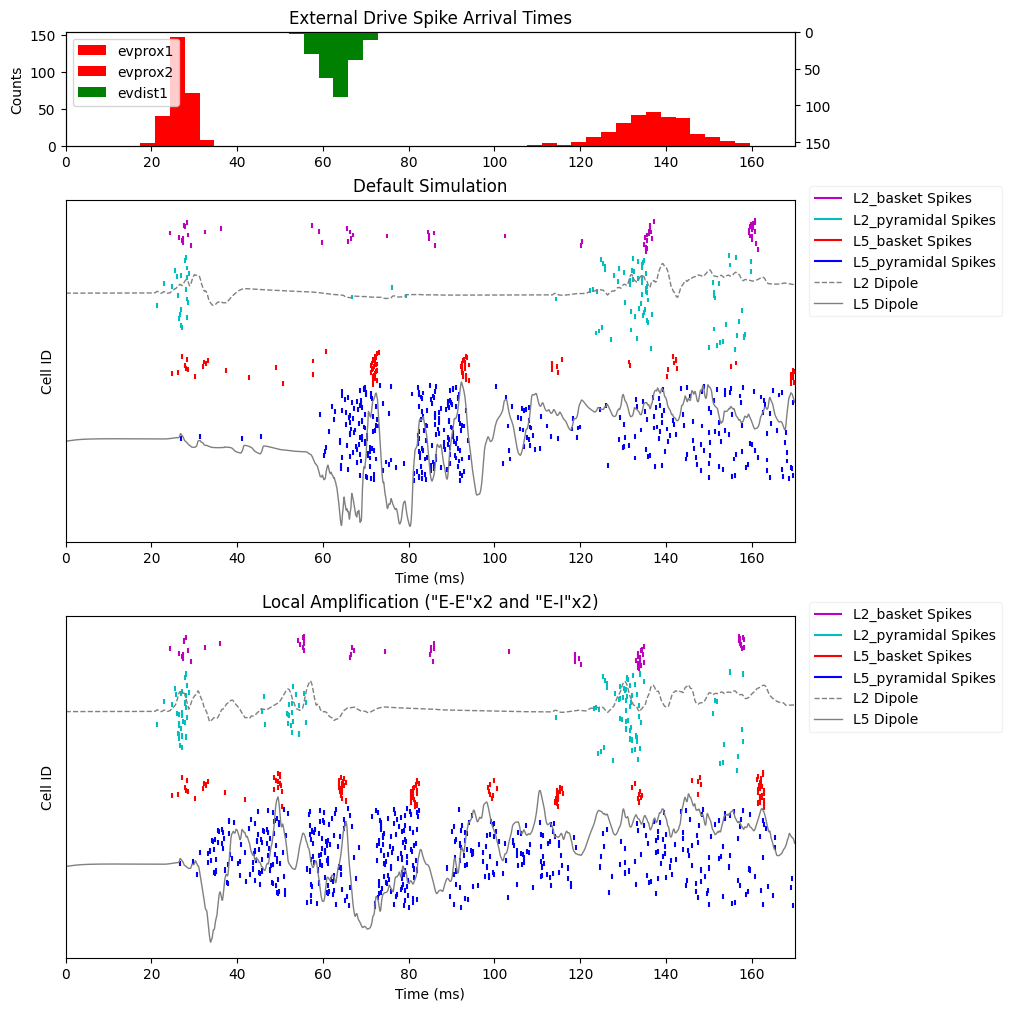

In [79]:
# get the unsmoothed dipole for the updated simulation
scaled_dipole_02_01 = net_02_dpl_01[0].scale(3000)

fig, axes = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(10, 10),
    gridspec_kw={"height_ratios": [1, 3, 3]},
    constrained_layout=True,
)

# plot the input histogram in the top subplot
custom_drive_hist(
    ax=axes[0],
    net=net_default,
)
# plot the spike rasters in the bottom subplots
custom_spikes_raster(
    ax=axes[1],
    net=net_default_gui,
    processed_dipole=unsmoothed_dipole,
)
axes[1].set_title("Default Simulation")

custom_spikes_raster(
    ax=axes[2],
    net=net_02_checkpoint_01,
    processed_dipole=scaled_dipole_02_01,
)
axes[2].set_title('Local Amplification ("E-E"x2 and "E-I"x2)');


We can see in the figure above that the two simulations have several differences in their underlying spiking activity. For the purpose of this exercise, let's identify three differences in the spiking activity in Layer 5 between the two simulations: 

  1. Around the time of the first proximal drive, there appears to be greater recruitment of pyramidal neurons in the "local amplification" simulation compared to the default simulation.

  2. The timing of pyramidal neuron and interneuron spiking appears to be shifted earlier in the "local amplification" simulation.

  3. There appears to be stronger, more synchronous interneuron spiking in the "local amplification" simulation around the second proximal drive. 

These observed differences highlight specific features of the circuit activity that we can investigate further. In particular, they give us *predictions* about which cell populations may be more strongly recruited, and how the timing of the activity may differ, between the neurotypical population (represented by the default simulation) and the ASD population (represented by the "local amplification" simulation).

We can then use these observations to identify targets for validation in follow-up experiments. For example, we could look for increased recruitment of pyramidal neurons during the early sensory response, or investigate whether the latency of the Layer 5 response differs for the ASD population. We could also examine whether inhibitory neurons show stronger or more synchronous activity during the corresponding response.

These are just a few examples of how model simulations can guide experimental validation. Rather than only comparing the aggregate dipoles between the model and the data, we can use the differences in underlying circuit activity to develop more specific predictions that can be tested with imaging, in vivo recordings, or other experimental modalities.